In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, r2_score
from sklearn.tree import plot_tree
import numpy as np

# df = pd.read_csv("merged_PrDeQuPeCOVID.csv", encoding='ISO-8859-1')

# print(df["ownership_type"].unique())

# # One-hot encode the 'Color' column
# df_encoded = pd.get_dummies(df, columns=["ownership_type", "provider_type"])

# # Binarize the Score column
# df_encoded['Score_High'] = df_encoded['overall_rating'] > 3

# # print(df_encoded)

# df_encoded.to_csv('FinalClean_COVID.csv', index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("merged_PrDeQuPe_data.csv", encoding='ISO-8859-1')

print(df["OWNERSHIP"].unique())

# One-hot encode the 'Color' column
df_encoded = pd.get_dummies(df, columns=["OWNERSHIP", "CERTIFICATION"])

# Binarize the Score column
df_encoded['Score_High'] = df_encoded['overall_rating'] > 3

# print(df_encoded)

df_encoded.to_csv('FinalClean_1519.csv', index=False)


['For profit' 'Non profit' 'Government']


In [5]:
import pandas as pd

df = pd.read_csv("FinalClean_151.csv", encoding='ISO-8859-1')
print(df["provnum"].value_counts())

provnum
15132     5
676338    5
15023     5
15116     5
15117     5
         ..
676412    1
676414    1
676415    1
676418    1
676419    1
Name: count, Length: 10790, dtype: int64


In [7]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("FinalClean_151.csv", encoding='ISO-8859-1')

# Ensure 'year' is an integer column (rename if it's named differently)
df['Year'] = df['Year'].astype(int)

# List of required years
required_years = [2015, 2016, 2017, 2018, 2019]

# Create a list to collect new rows
new_rows = []

# Group by provider number
for provnum, group in df.groupby('provnum'):
    existing_years = set(group['Year'])
    missing_years = set(required_years) - existing_years

    # If any years are missing
    if missing_years:
        # Compute the median of numeric columns for the group
        medians = group.median(numeric_only=True)

        for year in missing_years:
            new_row = medians.copy()
            new_row['provnum'] = provnum
            new_row['Year'] = year

            # Add other non-numeric columns if needed, here set as NaN or defaults
            for col in df.columns:
                if col not in new_row.index:
                    new_row[col] = np.nan

            new_rows.append(new_row)

# Add new rows to the original dataframe
if new_rows:
    df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

# Sort by provider and year
df = df.sort_values(by=['provnum', 'Year']).reset_index(drop=True)

# Save to a new CSV
df.to_csv('filled_output.csv', index=False)


In [10]:
def check_distribution_and_nulls(df):
    # Check for null values
    print("Null Values in Each Column:")
    print(df.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df.isnull().mean() * 100).round(2))

df = pd.read_csv("filled_output.csv", encoding='ISO-8859-1')
# check_distribution_and_nulls(df)

# One-hot encode the 'Color' column
df_encoded = pd.get_dummies(df, columns=["ZIPREGION"])

# print(df_encoded)
df_encoded.to_csv('FinalClean_15.csv', index=False)

In [13]:
import pandas as pd

# Load both CSV files
df1 = pd.read_csv("FinalClean_COVID.csv")  # Left table
df2 = pd.read_csv("20_21.zips.csv")  # Right table

df1['federal_provider_number'] = df1['federal_provider_number'].astype(str)
df2['federal_provider_number'] = df2['federal_provider_number'].astype(str)

# Then perform your merge
merged_df = pd.merge(df1, df2, on="federal_provider_number", how="left")

# Perform a left merge on a common column (e.g., 'provnum')
merged_df = pd.merge(df1, df2, on=["federal_provider_number", "year"], how="left")

# Save the merged DataFrame
merged_df.to_csv("left_merged_COVID.csv", index=False)


In [ ]:
def check_distribution_and_nulls(df):
    # Check for null values
    print("Null Values in Each Column:")
    print(df.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df.isnull().mean() * 100).round(2))

df = pd.read_csv("left_merged_COVID.csv", encoding='ISO-8859-1')
# check_distribution_and_nulls(df)

# One-hot encode the 'Color' column
df_encoded = pd.get_dummies(df, columns=["ZIPREGION"])

# print(df_encoded)
df_encoded.to_csv('left_merged_ZIP_COVID.csv', index=False)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load your data
df = pd.read_csv("FinalClean_15.csv")

# Step 2: Binarize the target variable
threshold = df['Score_High'].median()
df['Score_High_Binary'] = (df['Score_High'] >= threshold).astype(int)

# Step 3: Manually select independent variables
s_f1 = ["quality_rating", "staffing_rating", "DeficiencyCount", "adj_total"]
print(s_f1)

# s_f2 = ["short_stay_poor_quality", "short_stay_good_quality", "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"]
# print(s_f2)

X = df[s_f1]
# X = df[s_f2]
y = df["Score_High_Binary"]

# Optional: One-hot encode if you have categorical features
X = pd.get_dummies(X, drop_first=True)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature scaling (only for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------
# Model 1: Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

# ----------------------
# Model 2: Decision Tree (no scaling needed)
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

# ----------------------
# Model 3: Random Forest (no scaling needed)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


['quality_rating', 'staffing_rating', 'DeficiencyCount', 'adj_total']
=== Logistic Regression ===
Accuracy: 0.7988138263367621
Confusion Matrix:
 [[3908 1170]
 [1001 4712]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.78      5078
           1       0.80      0.82      0.81      5713

    accuracy                           0.80     10791
   macro avg       0.80      0.80      0.80     10791
weighted avg       0.80      0.80      0.80     10791


=== Decision Tree ===
Accuracy: 0.8593272171253823
Confusion Matrix:
 [[4326  752]
 [ 766 4947]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      5078
           1       0.87      0.87      0.87      5713

    accuracy                           0.86     10791
   macro avg       0.86      0.86      0.86     10791
weighted avg       0.86      0.86      0.86     10791


=== Random Forest ===
Accu

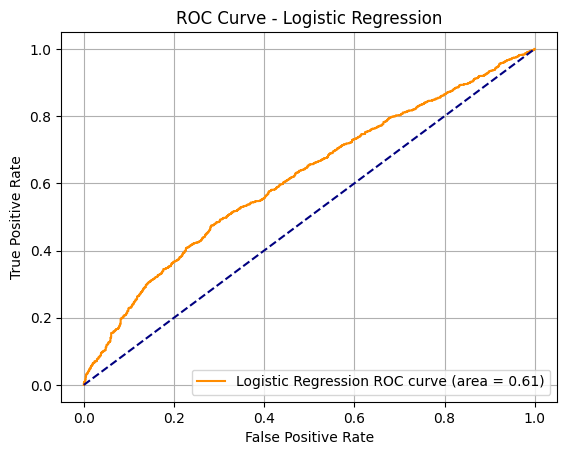

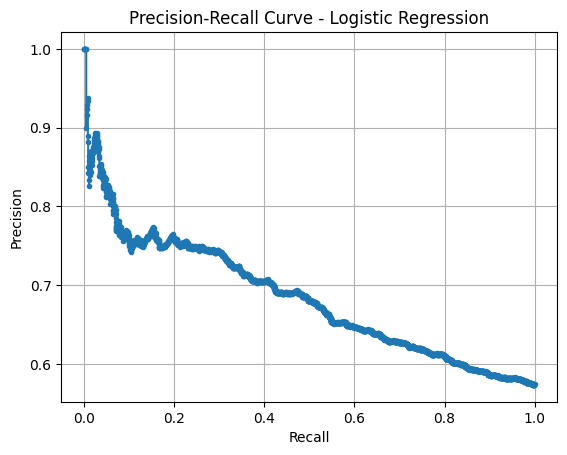

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, r2_score
from sklearn.tree import plot_tree
import numpy as np


# Predict probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'Logistic Regression ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_log)

plt.figure()
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

In [2]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("Nearfinal_NEEDSallyears_COVID.csv", encoding='ISO-8859-1')

# Ensure 'year' is an integer column (rename if it's named differently)
df['Year'] = df['Year'].astype(int)

# List of required years
required_years = [2020, 2021]

# Create a list to collect new rows
new_rows = []

# Group by provider number
for provnum, group in df.groupby('provnum'):
    existing_years = set(group['Year'])
    missing_years = set(required_years) - existing_years

    # If any years are missing
    if missing_years:
        # Compute the median of numeric columns for the group
        medians = group.median(numeric_only=True)

        for year in missing_years:
            new_row = medians.copy()
            new_row['provnum'] = provnum
            new_row['Year'] = year

            # Add other non-numeric columns if needed, here set as NaN or defaults
            for col in df.columns:
                if col not in new_row.index:
                    new_row[col] = np.nan

            new_rows.append(new_row)

# Add new rows to the original dataframe
if new_rows:
    df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

# Sort by provider and year
df = df.sort_values(by=['provnum', 'Year']).reset_index(drop=True)

# Save to a new CSV
df.to_csv('FinalClean_COVID.csv', index=False)


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load your data
df = pd.read_csv("FinalClean_15.csv")

# Filter the DataFrame to include only rows where 'year' is 2018 or 2019
df = df[df['Year'].isin([2018, 2019])]

# Step 2: Binarize the target variable
threshold = df['Score_High'].median()
df['Score_High_Binary'] = (df['Score_High'] >= threshold).astype(int)

# Step 3: Manually select independent variables
s_f1 = ["quality_rating", "staffing_rating", "DeficiencyCount", "adj_total",
        "short_stay_poor_quality", "short_stay_good_quality", "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"]
print(s_f1)

# s_f2 = ["short_stay_poor_quality", "short_stay_good_quality", "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"]
# print(s_f2)

X = df[s_f1]
# X = df[s_f2]
y = df["Score_High_Binary"]

# Optional: One-hot encode if you have categorical features
X = pd.get_dummies(X, drop_first=True)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature scaling (only for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------
# Model 1: Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

# ----------------------
# Model 2: Decision Tree (no scaling needed)
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

# ----------------------
# Model 3: Random Forest (no scaling needed)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


['quality_rating', 'staffing_rating', 'DeficiencyCount', 'adj_total', 'short_stay_poor_quality', 'short_stay_good_quality', 'long_stay_poor_quality', 'long_stay_good_quality', 'measure_score_qtravg']
=== Logistic Regression ===
Accuracy: 0.8018999073215941
Confusion Matrix:
 [[1538  478]
 [ 377 1923]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78      2016
           1       0.80      0.84      0.82      2300

    accuracy                           0.80      4316
   macro avg       0.80      0.80      0.80      4316
weighted avg       0.80      0.80      0.80      4316


=== Decision Tree ===
Accuracy: 0.8403614457831325
Confusion Matrix:
 [[1659  357]
 [ 332 1968]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.83      2016
           1       0.85      0.86      0.85      2300

    accuracy                           0.84      4316
   mac

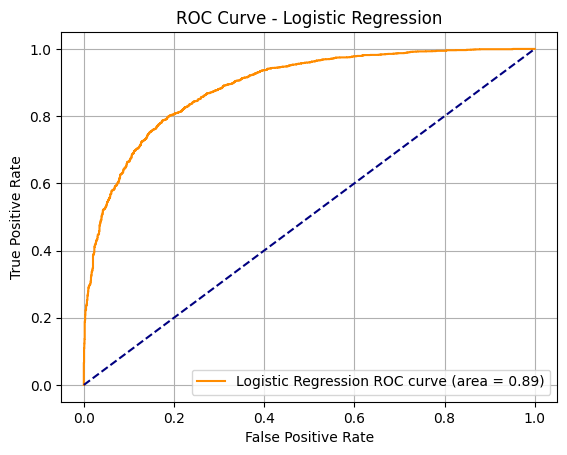

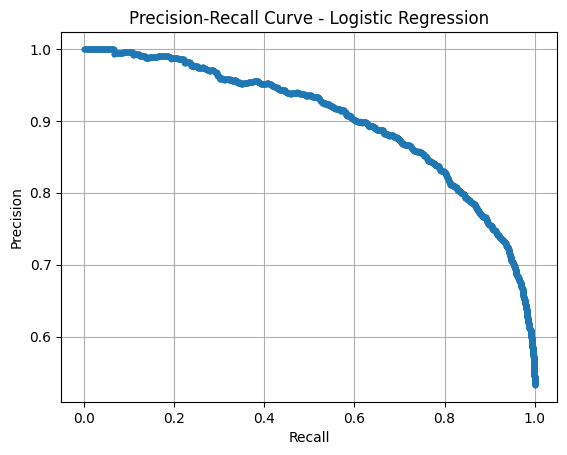

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, r2_score
from sklearn.tree import plot_tree
import numpy as np


# Predict probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'Logistic Regression ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_log)

plt.figure()
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

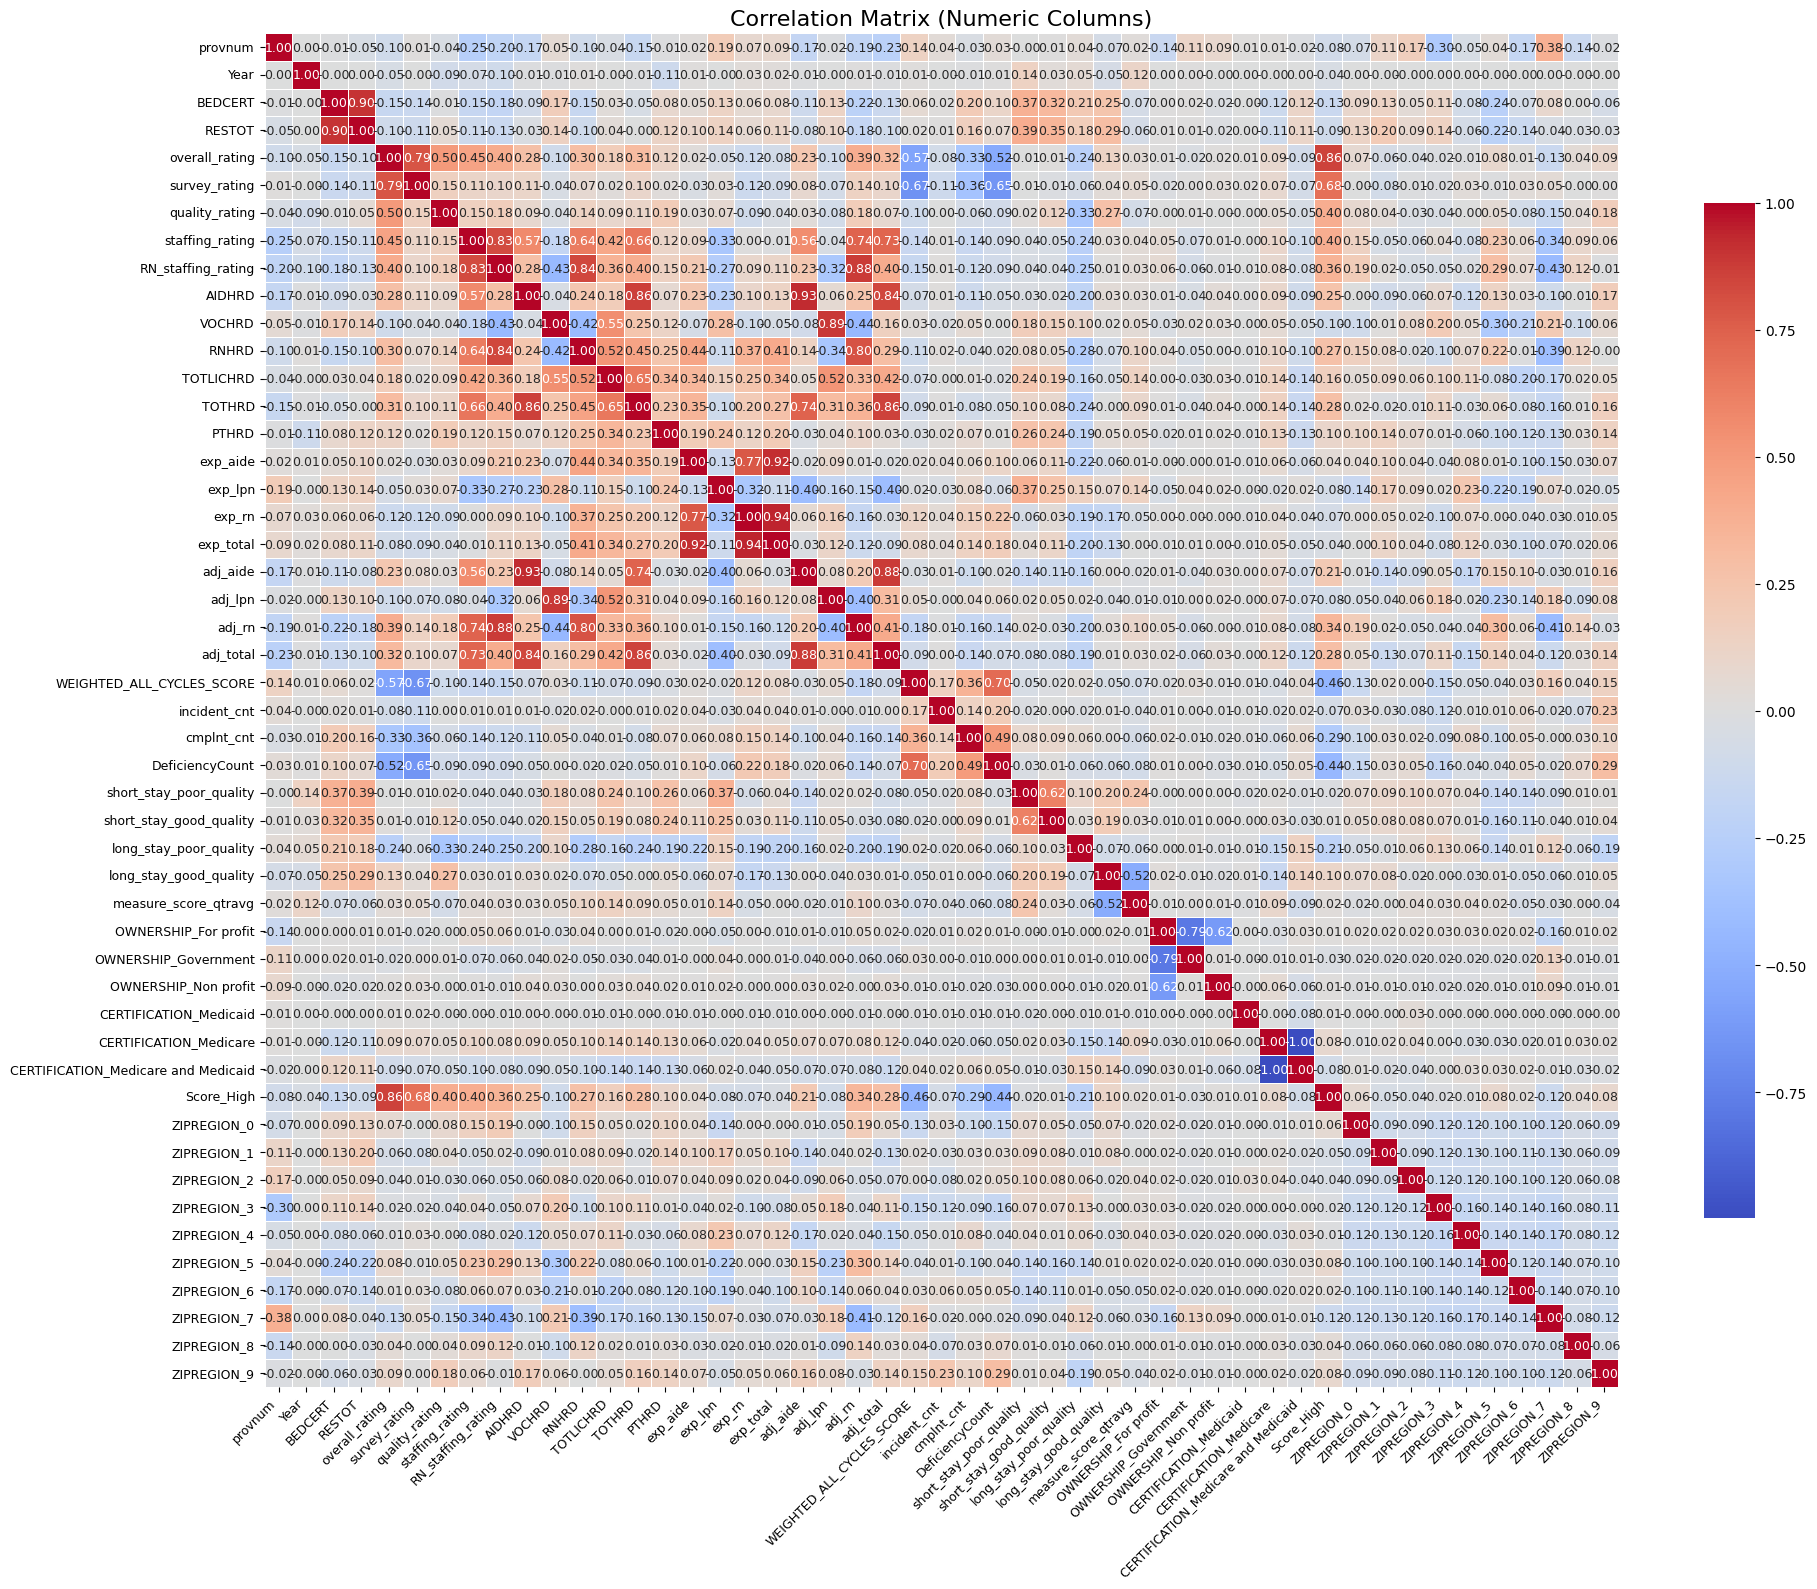

Top 20 variables most correlated with Score_High:

overall_rating               0.858556
survey_rating                0.680999
WEIGHTED_ALL_CYCLES_SCORE   -0.461170
DeficiencyCount             -0.439284
staffing_rating              0.397996
quality_rating               0.397789
RN_staffing_rating           0.359251
adj_rn                       0.339699
cmplnt_cnt                  -0.286377
adj_total                    0.282457
TOTHRD                       0.275364
RNHRD                        0.273706
AIDHRD                       0.251534
adj_aide                     0.213447
long_stay_poor_quality      -0.209689
TOTLICHRD                    0.159293
BEDCERT                     -0.134627
ZIPREGION_7                 -0.117141
long_stay_good_quality       0.103834
VOCHRD                      -0.099835
Name: Score_High, dtype: float64


In [4]:
# Step 1: Load your data
df = pd.read_csv("FinalClean_15.csv")

# Filter the DataFrame to include only rows where 'year' is 2018 or 2019
df = df[df['Year'].isin([2018, 2019])]

# Select numeric columns only (recommended)
df_numeric = df.select_dtypes(include='number')

# Compute correlation matrix
corr = df_numeric.corr()

# Set up the matplotlib figure with a larger size
plt.figure(figsize=(20, 16))  # You can adjust size as needed

# Draw the heatmap with better spacing and larger fonts
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 9},    # Font size of the correlation numbers
    linewidths=0.5,            # Add grid lines
    square=True,               # Make cells square
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Tweak tick label font size and rotation
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title("Correlation Matrix (Numeric Columns)", fontsize=16)
plt.tight_layout()
plt.show()

# Extract correlations with 'Score_High'
score_corr = corr['Score_High'].drop('Score_High')  # drop self-correlation (1.0)

# Sort by absolute correlation value (descending)
sorted_corr = score_corr.reindex(score_corr.abs().sort_values(ascending=False).index)

# Display top N strongest correlations (positive or negative)
top_n = 20
print(f"Top {top_n} variables most correlated with Score_High:\n")
print(sorted_corr.head(top_n))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load your data
df = pd.read_csv("FinalClean_COVID.csv")

# Step 2: Binarize the target variable
threshold = df['Score_High'].median()
df['Score_High_Binary'] = (df['Score_High'] >= threshold).astype(int)

# Step 3: Manually select independent variables
s_f1 = ["quality_rating", "staffing_rating", "DeficiencyCount", "adj_total","WEIGHTED_ALL_CYCLES_SCORE", 
        "cmplnt_cnt", "BEDCERT", "RESTOT", "short_stay_poor_quality", "short_stay_good_quality", "long_stay_poor_quality",
        "long_stay_good_quality", "measure_score_qtravg", "OWNERSHIP_For profit", "OWNERSHIP_Government", "OWNERSHIP_Non profit",
        "CERTIFICATION_Medicaid", "CERTIFICATION_Medicare", "CERTIFICATION_Medicare and Medicaid"
        ]
print(s_f1)

# s_f1 = ["ZIPREGION_0", "ZIPREGION_9", "ZIPREGION_7", "ZIPREGION_1", "ZIPREGION_8",
#  "ZIPREGION_2", "RESTOT", "WEIGHTED_ALL_CYCLES_SCORE", "ZIPREGION_6", "RNHRD", "ZIPREGION_3"]

# print(s_f1)

X = df[s_f1]
# X = df[s_f2]
y = df["Score_High_Binary"]

# Optional: One-hot encode if you have categorical features
X = pd.get_dummies(X, drop_first=True)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature scaling (only for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------
# Model 1: Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

# ----------------------
# Model 2: Decision Tree (no scaling needed)
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

# ----------------------
# Model 3: Random Forest (no scaling needed)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


['quality_rating', 'staffing_rating', 'DeficiencyCount', 'adj_total', 'WEIGHTED_ALL_CYCLES_SCORE', 'cmplnt_cnt', 'BEDCERT', 'RESTOT', 'short_stay_poor_quality', 'short_stay_good_quality', 'long_stay_poor_quality', 'long_stay_good_quality', 'measure_score_qtravg', 'OWNERSHIP_For profit', 'OWNERSHIP_Government', 'OWNERSHIP_Non profit', 'CERTIFICATION_Medicaid', 'CERTIFICATION_Medicare', 'CERTIFICATION_Medicare and Medicaid']
['quality_rating', 'staffing_rating', 'DeficiencyCount', 'adj_total', 'WEIGHTED_ALL_CYCLES_SCORE', 'cmplnt_cnt', 'BEDCERT', 'RESTOT', 'short_stay_poor_quality', 'short_stay_good_quality', 'long_stay_poor_quality', 'long_stay_good_quality', 'measure_score_qtravg', 'OWNERSHIP_For profit', 'OWNERSHIP_Government', 'OWNERSHIP_Non profit', 'CERTIFICATION_Medicaid', 'CERTIFICATION_Medicare', 'CERTIFICATION_Medicare and Medicaid']
=== Logistic Regression ===
Accuracy: 0.7198483804272915
Confusion Matrix:
 [[ 777  460]
 [ 353 1312]]
Classification Report:
               preci

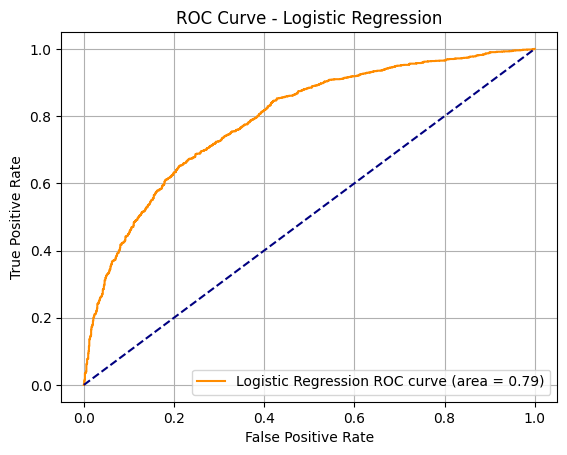

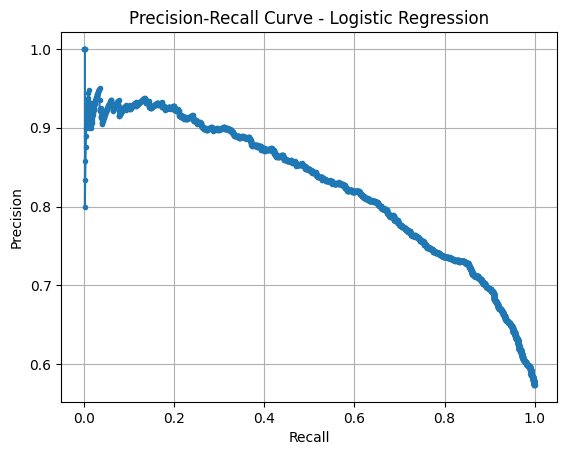

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, r2_score
from sklearn.tree import plot_tree
import numpy as np


# Predict probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'Logistic Regression ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_log)

plt.figure()
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

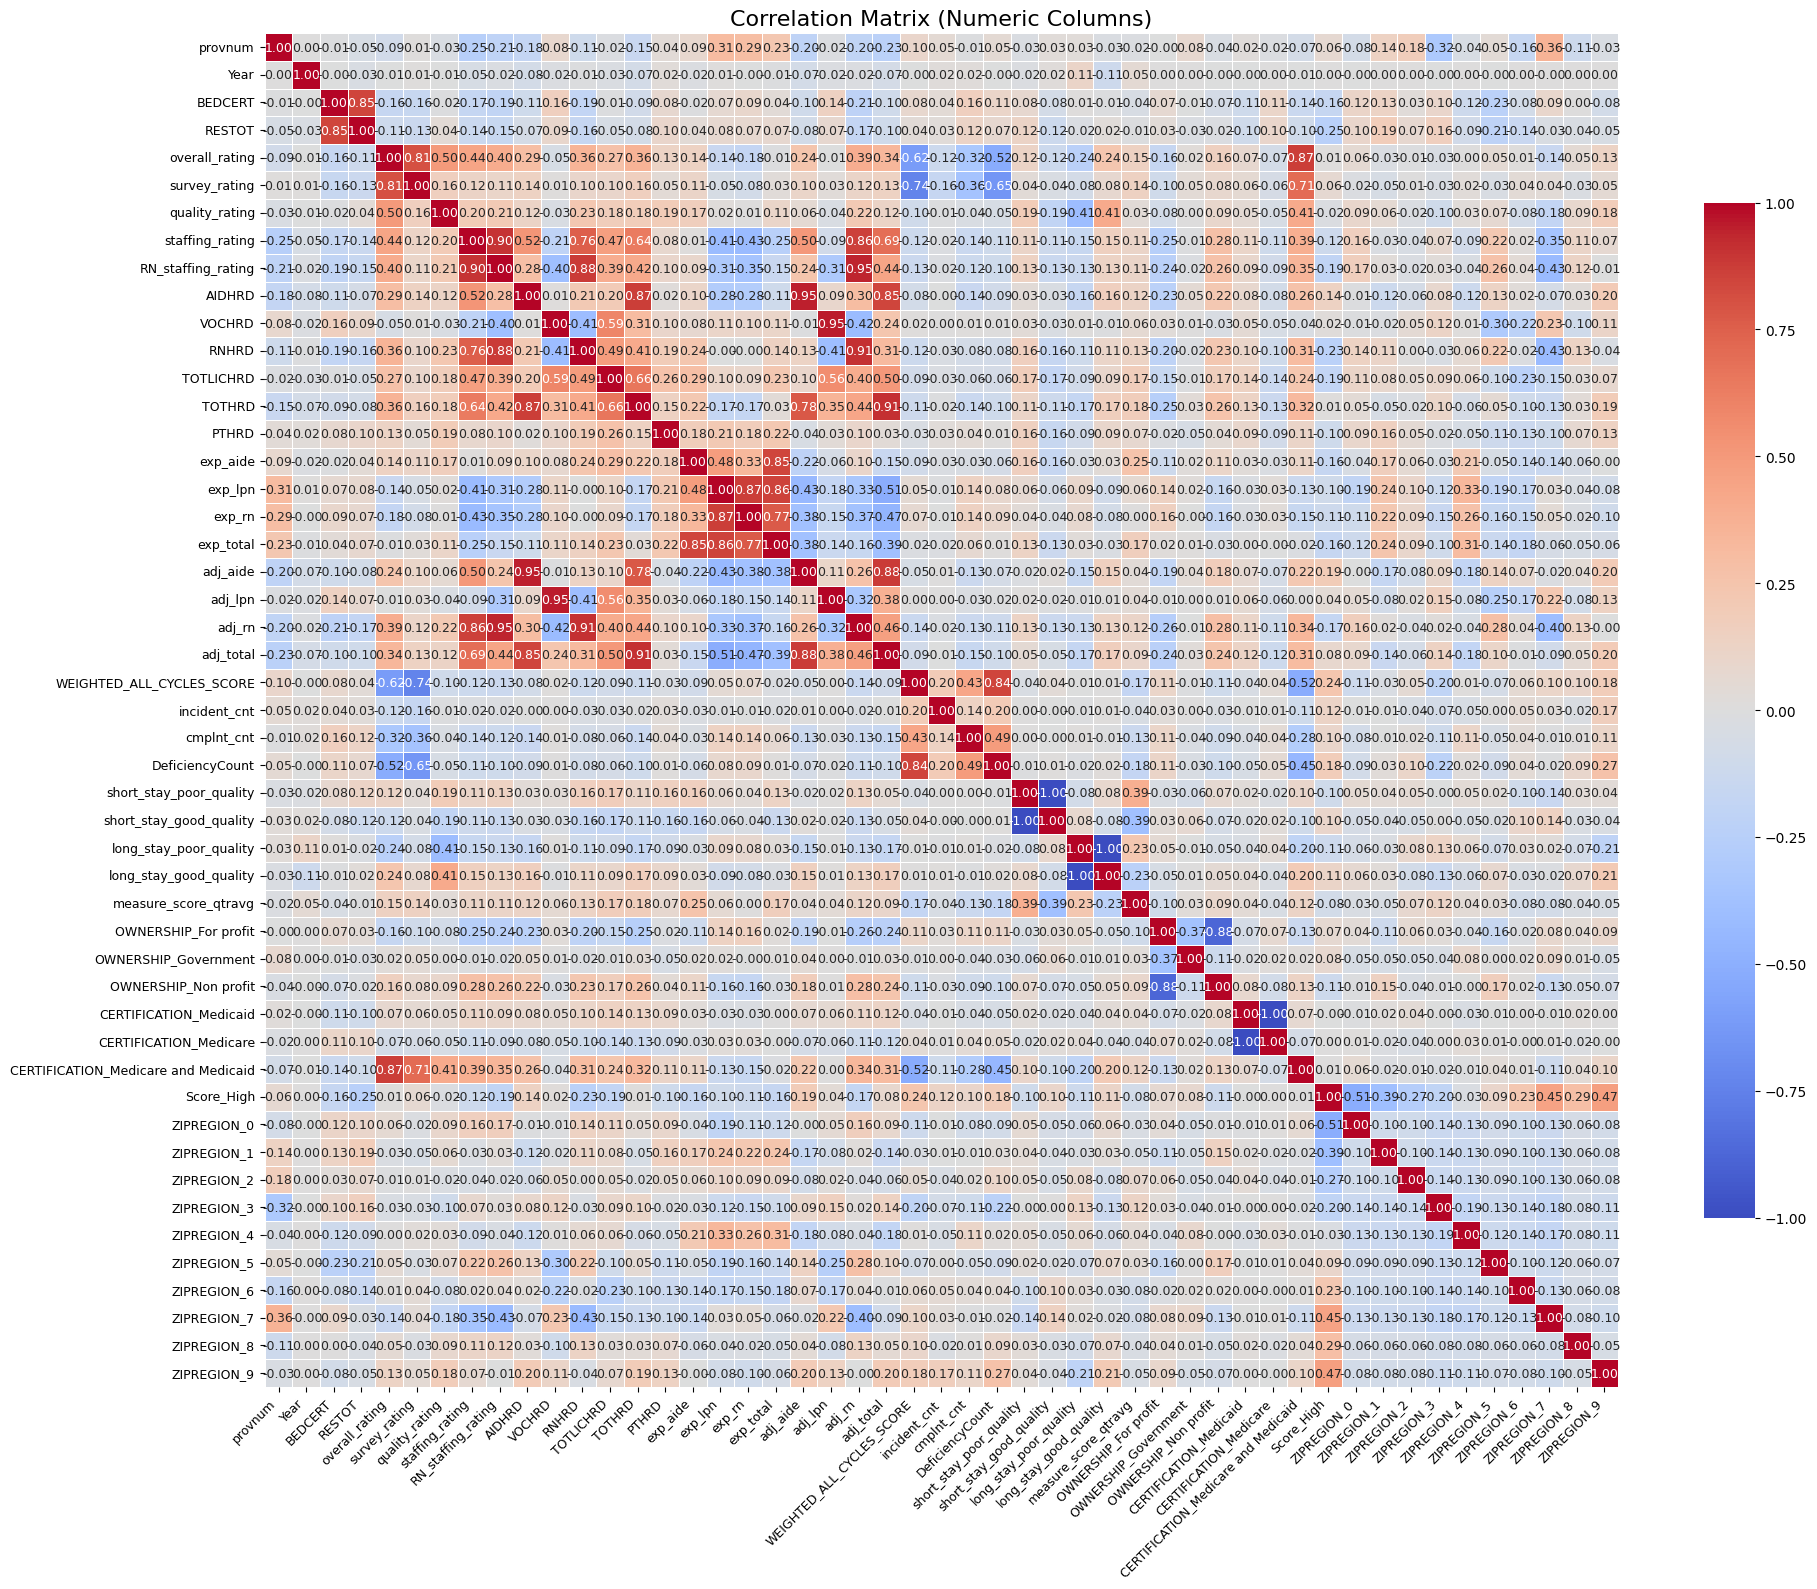

Top 20 variables most correlated with Score_High:

ZIPREGION_0                 -0.509066
ZIPREGION_9                  0.474365
ZIPREGION_7                  0.452450
ZIPREGION_1                 -0.392525
ZIPREGION_8                  0.287705
ZIPREGION_2                 -0.266814
RESTOT                      -0.247882
WEIGHTED_ALL_CYCLES_SCORE    0.239483
ZIPREGION_6                  0.232752
RNHRD                       -0.231082
ZIPREGION_3                 -0.203025
adj_aide                     0.193016
RN_staffing_rating          -0.187922
TOTLICHRD                   -0.186849
DeficiencyCount              0.180125
adj_rn                      -0.166520
exp_aide                    -0.161106
exp_total                   -0.159161
BEDCERT                     -0.157141
AIDHRD                       0.140454
Name: Score_High, dtype: float64


In [5]:
# Step 1: Load your data
df = pd.read_csv("FinalClean_COVID.csv")

# Select numeric columns only (recommended)
df_numeric = df.select_dtypes(include='number')

# Compute correlation matrix
corr = df_numeric.corr()

# Set up the matplotlib figure with a larger size
plt.figure(figsize=(20, 16))  # You can adjust size as needed

# Draw the heatmap with better spacing and larger fonts
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 9},    # Font size of the correlation numbers
    linewidths=0.5,            # Add grid lines
    square=True,               # Make cells square
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Tweak tick label font size and rotation
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title("Correlation Matrix (Numeric Columns)", fontsize=16)
plt.tight_layout()
plt.show()

# Extract correlations with 'Score_High'
score_corr = corr['Score_High'].drop('Score_High')  # drop self-correlation (1.0)

# Sort by absolute correlation value (descending)
sorted_corr = score_corr.reindex(score_corr.abs().sort_values(ascending=False).index)

# Display top N strongest correlations (positive or negative)
top_n = 20
print(f"Top {top_n} variables most correlated with Score_High:\n")
print(sorted_corr.head(top_n))


In [11]:
import pandas as pd

# Load both datasets
df1 = pd.read_csv("FinalClean_Regression.csv")
df2 = pd.read_csv("FinalCategorizationProvider_Data.csv")  # Replace with your actual second file

# OPTIONAL: Strip any extra spaces in column names (recommended)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

df1[['provnum', 'Year']] = df1[['provnum', 'Year']].astype(str)
df2[['provnum', 'Year']] = df2[['provnum', 'Year']].astype(str)

# Now merge on 'provnum' and 'Year'
merged_df = pd.merge(df1, df2, on=["provnum", "Year"], how="inner")

merged_df.to_csv('RetirementCareData.csv', index=False)

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load your data
df_original = pd.read_csv("FinalClean_15.csv")

# List of ZIPREGION columns
zipregion_cols = [f'ZIPREGION_{i}' for i in range(1, 10)]

# List to track skipped regions
skipped_regions = []

# Loop through each ZIPREGION column
for zip_col in zipregion_cols:
    print(f"\n\n========== Analysis for {zip_col} ==========\n")

    # Filter rows where this region is active
    df = df_original[df_original[zip_col] == 1].copy()

    # Skip if too few rows to model
    if df.shape[0] < 50:
        print(f"Skipping {zip_col} — not enough data ({df.shape[0]} rows).")
        skipped_regions.append((zip_col, "Too few rows", df.shape[0]))
        continue

    # Filter to 2018 and 2019
    df = df[df['Year'].isin([2018, 2019])]

    # Create binary target variable
    threshold = df['Score_High'].median()
    df['Score_High_Binary'] = (df['Score_High'] >= threshold).astype(int)

    y = df["Score_High_Binary"]

    # Skip if only one class present
    if y.nunique() < 2:
        dominant_class = y.unique()[0]
        print(f"Skipping {zip_col} — only one class present: {dominant_class}")
        skipped_regions.append((zip_col, f"Only class {dominant_class}", len(y)))
        continue

    # Feature selection
    s_f1 = ["quality_rating", "staffing_rating", "DeficiencyCount", "adj_total",
            "short_stay_poor_quality", "short_stay_good_quality",
            "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"]

    X = df[s_f1]
    y = df["Score_High_Binary"]

    # One-hot encoding (if needed)
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    # Feature scaling for logistic regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    log_model = LogisticRegression()
    log_model.fit(X_train_scaled, y_train)
    y_pred_log = log_model.predict(X_test_scaled)

    print("=== Logistic Regression ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_log))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
    print("Classification Report:\n", classification_report(y_test, y_pred_log))

    # Decision Tree
    tree_model = DecisionTreeClassifier(random_state=42)
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    print("\n=== Decision Tree ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_tree))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
    print("Classification Report:\n", classification_report(y_test, y_pred_tree))

    # Random Forest
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    print("\n=== Random Forest ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# After all regions are processed
if skipped_regions:
    print("\n=== Skipped ZIPREGIONs Summary ===")
    for region, reason, count in skipped_regions:
        print(f"{region}: {reason} ({count} rows)")

    # Save skipped summary to CSV
    skipped_df = pd.DataFrame(skipped_regions, columns=['ZIPREGION', 'Reason', 'Row_Count'])
    skipped_df.to_csv("Skipped_Regions_Summary.csv", index=False)
    print("\nSkipped regions exported to Skipped_Regions_Summary.csv")
else:
    print("\nAll ZIPREGIONs included — no regions skipped.")




========== Analysis for ZIPREGION_1 ==========

Skipping ZIPREGION_1 — only one class present: 1


========== Analysis for ZIPREGION_2 ==========

=== Logistic Regression ===
Accuracy: 0.7965116279069767
Confusion Matrix:
 [[143  38]
 [ 32 131]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80       181
           1       0.78      0.80      0.79       163

    accuracy                           0.80       344
   macro avg       0.80      0.80      0.80       344
weighted avg       0.80      0.80      0.80       344


=== Decision Tree ===
Accuracy: 0.8372093023255814
Confusion Matrix:
 [[149  32]
 [ 24 139]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       181
           1       0.81      0.85      0.83       163

    accuracy                           0.84       344
   macro avg       0.84      0.84      0.84       344
weighted av



========== Analysis for ZIPREGION_1 ==========

Skipping ZIPREGION_1 — only one class present: 1


========== Analysis for ZIPREGION_2 ==========

=== Logistic Regression ===
Accuracy: 0.7965116279069767
Confusion Matrix:
 [[143  38]
 [ 32 131]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80       181
           1       0.78      0.80      0.79       163

    accuracy                           0.80       344
   macro avg       0.80      0.80      0.80       344
weighted avg       0.80      0.80      0.80       344


=== Decision Tree ===
Accuracy: 0.8372093023255814
Confusion Matrix:
 [[149  32]
 [ 24 139]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       181
           1       0.81      0.85      0.83       163

    accuracy                           0.84       344
   macro avg       0.84      0.84      0.84       344
weighted av

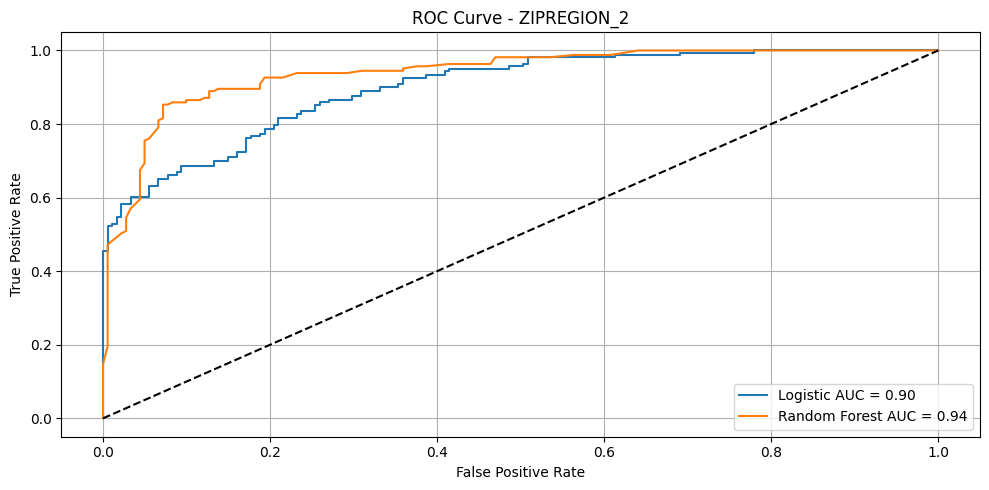

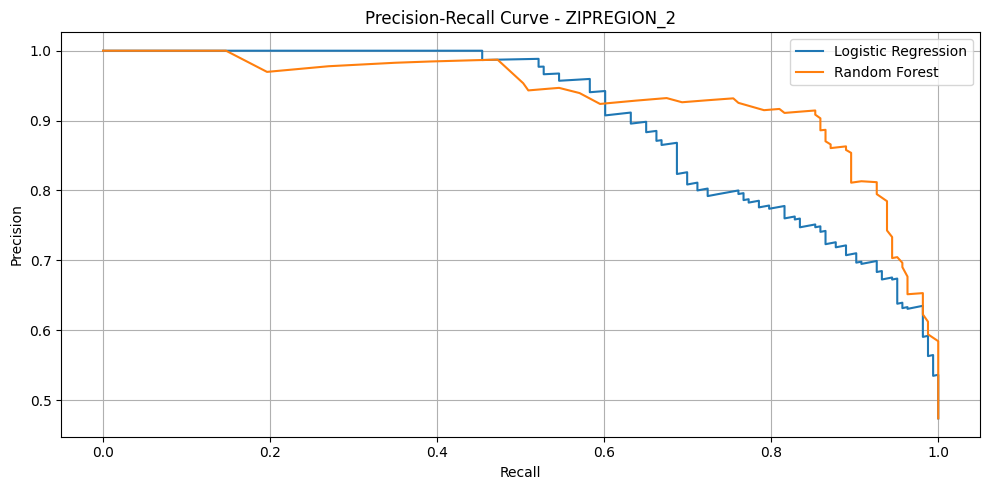



========== Analysis for ZIPREGION_3 ==========

=== Logistic Regression ===
Accuracy: 0.8091993185689949
Confusion Matrix:
 [[193  65]
 [ 47 282]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.78       258
           1       0.81      0.86      0.83       329

    accuracy                           0.81       587
   macro avg       0.81      0.80      0.80       587
weighted avg       0.81      0.81      0.81       587


=== Decision Tree ===
Accuracy: 0.8432708688245315
Confusion Matrix:
 [[212  46]
 [ 46 283]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       258
           1       0.86      0.86      0.86       329

    accuracy                           0.84       587
   macro avg       0.84      0.84      0.84       587
weighted avg       0.84      0.84      0.84       587


=== Random Forest ===
Accuracy: 0.889267461669506
Conf

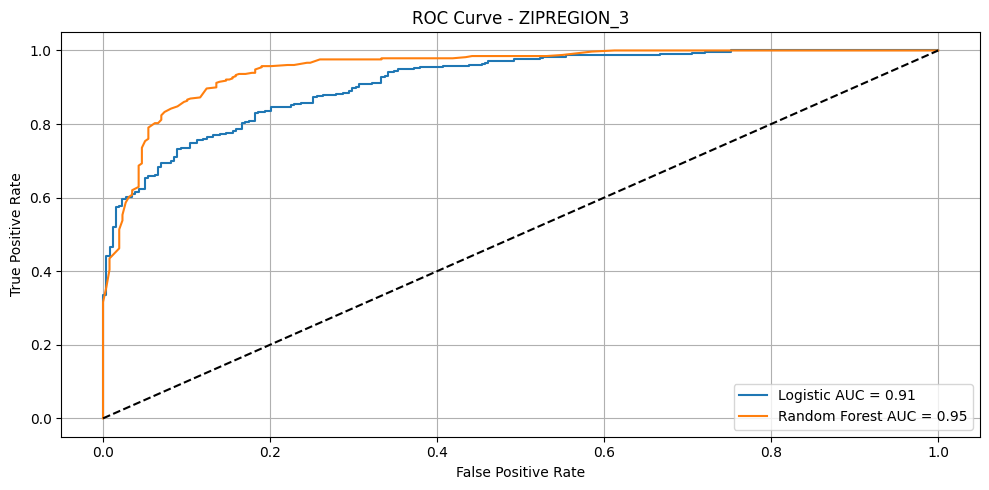

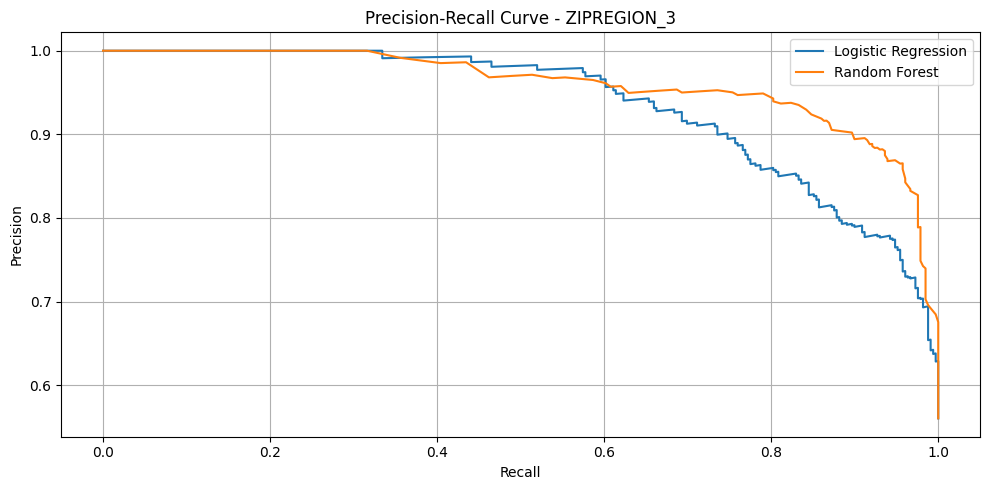



========== Analysis for ZIPREGION_4 ==========

=== Logistic Regression ===
Accuracy: 0.807936507936508
Confusion Matrix:
 [[190  59]
 [ 62 319]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.76      0.76       249
           1       0.84      0.84      0.84       381

    accuracy                           0.81       630
   macro avg       0.80      0.80      0.80       630
weighted avg       0.81      0.81      0.81       630


=== Decision Tree ===
Accuracy: 0.8920634920634921
Confusion Matrix:
 [[219  30]
 [ 38 343]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87       249
           1       0.92      0.90      0.91       381

    accuracy                           0.89       630
   macro avg       0.89      0.89      0.89       630
weighted avg       0.89      0.89      0.89       630


=== Random Forest ===
Accuracy: 0.9222222222222223
Conf

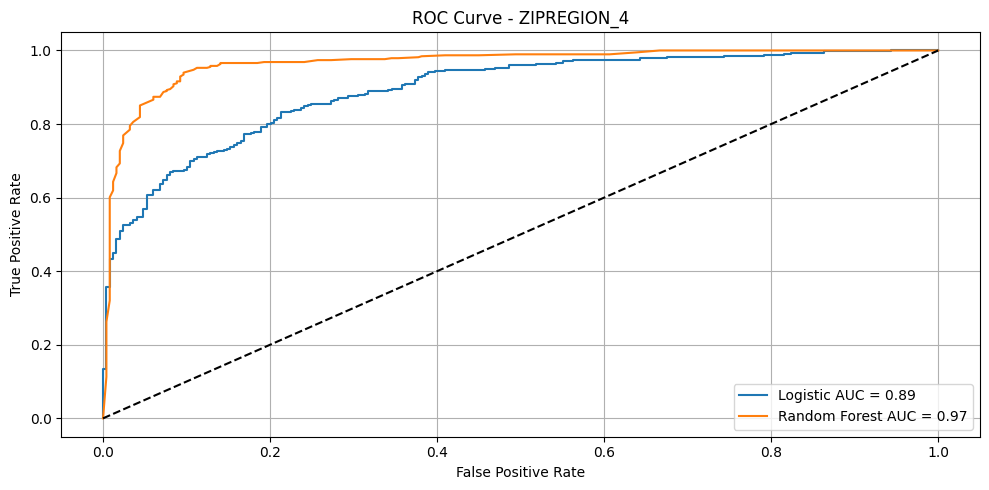

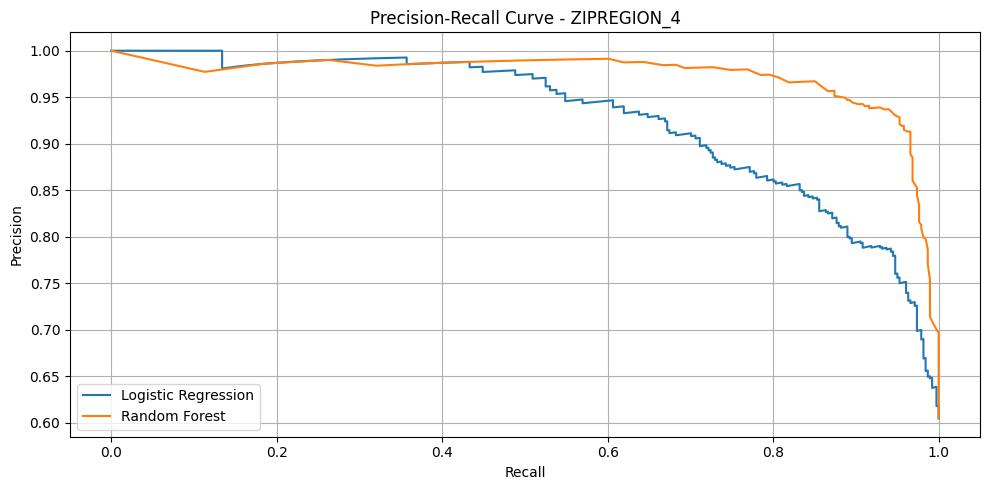



========== Analysis for ZIPREGION_5 ==========

=== Logistic Regression ===
Accuracy: 0.8650442477876106
Confusion Matrix:
 [[ 93  42]
 [ 19 298]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       135
           1       0.88      0.94      0.91       317

    accuracy                           0.87       452
   macro avg       0.85      0.81      0.83       452
weighted avg       0.86      0.87      0.86       452


=== Decision Tree ===
Accuracy: 0.9026548672566371
Confusion Matrix:
 [[111  24]
 [ 20 297]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83       135
           1       0.93      0.94      0.93       317

    accuracy                           0.90       452
   macro avg       0.89      0.88      0.88       452
weighted avg       0.90      0.90      0.90       452


=== Random Forest ===
Accuracy: 0.9247787610619469
Con

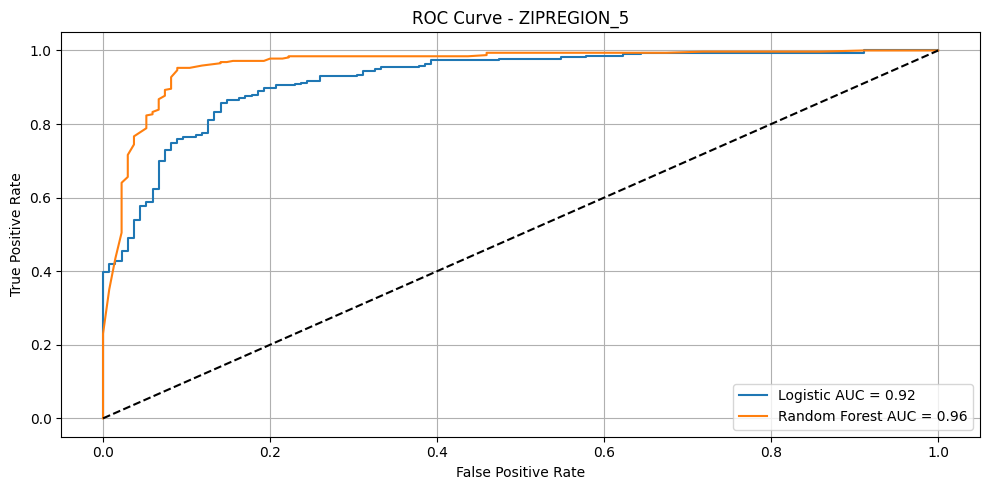

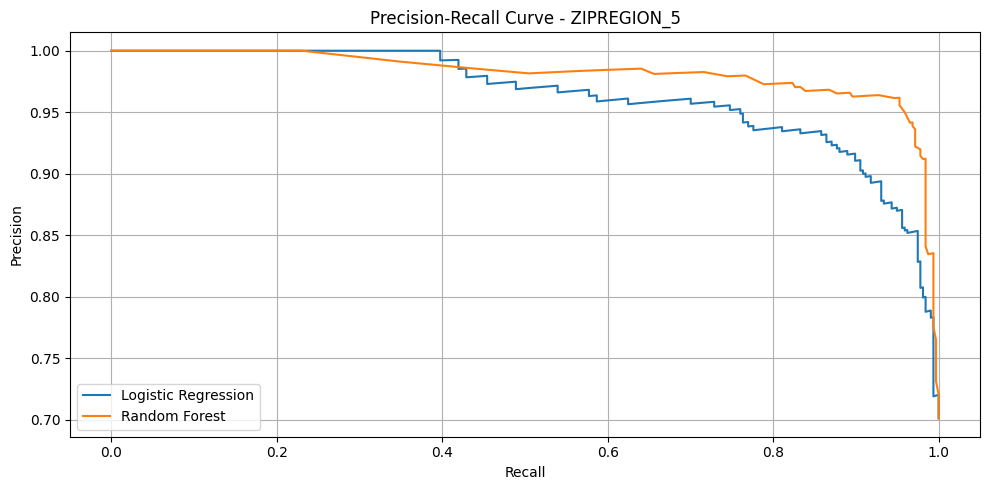



========== Analysis for ZIPREGION_6 ==========

=== Logistic Regression ===
Accuracy: 0.789010989010989
Confusion Matrix:
 [[116  55]
 [ 41 243]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.68      0.71       171
           1       0.82      0.86      0.84       284

    accuracy                           0.79       455
   macro avg       0.78      0.77      0.77       455
weighted avg       0.79      0.79      0.79       455


=== Decision Tree ===
Accuracy: 0.8725274725274725
Confusion Matrix:
 [[150  21]
 [ 37 247]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       171
           1       0.92      0.87      0.89       284

    accuracy                           0.87       455
   macro avg       0.86      0.87      0.87       455
weighted avg       0.88      0.87      0.87       455


=== Random Forest ===
Accuracy: 0.8703296703296703
Conf

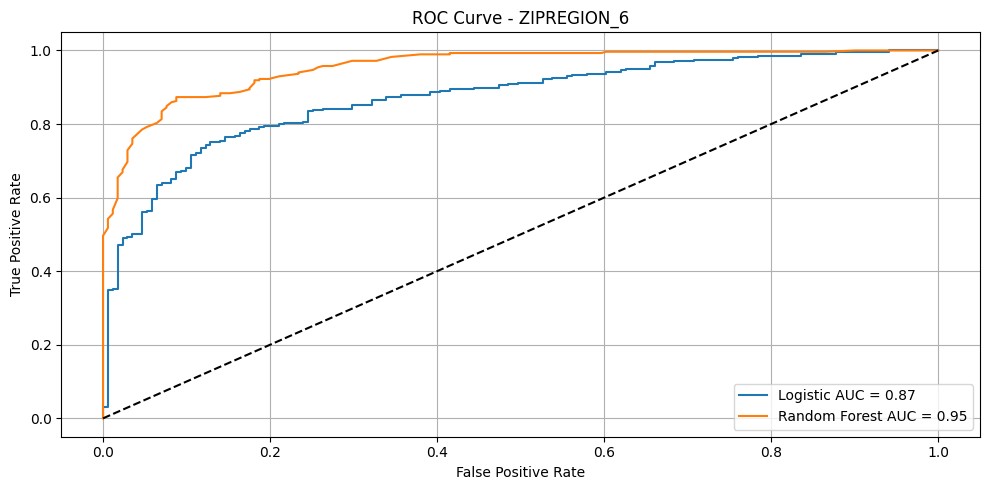

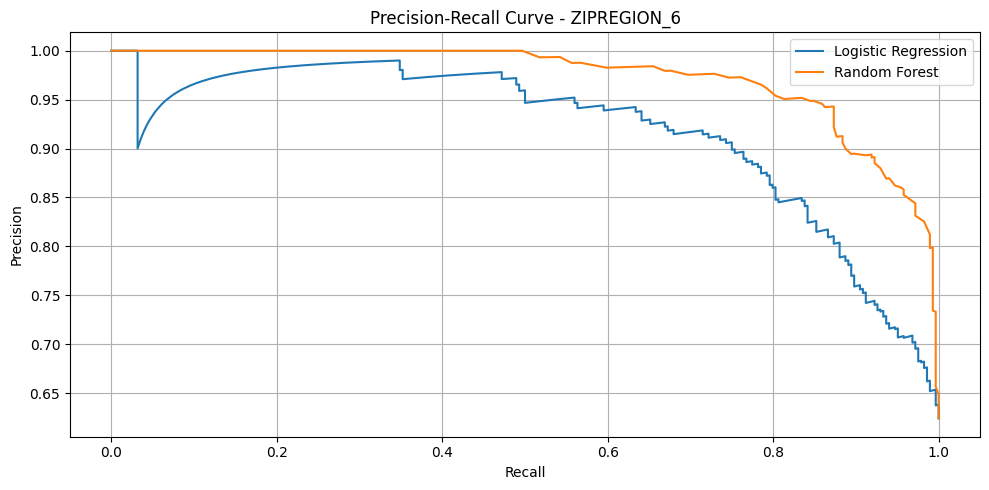



========== Analysis for ZIPREGION_7 ==========

Skipping ZIPREGION_7 — only one class present: 1


========== Analysis for ZIPREGION_8 ==========

=== Logistic Regression ===
Accuracy: 0.8245614035087719
Confusion Matrix:
 [[ 28  22]
 [  8 113]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.56      0.65        50
           1       0.84      0.93      0.88       121

    accuracy                           0.82       171
   macro avg       0.81      0.75      0.77       171
weighted avg       0.82      0.82      0.82       171


=== Decision Tree ===
Accuracy: 0.847953216374269
Confusion Matrix:
 [[ 35  15]
 [ 11 110]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.70      0.73        50
           1       0.88      0.91      0.89       121

    accuracy                           0.85       171
   macro avg       0.82      0.80      0.81       171
weighted avg

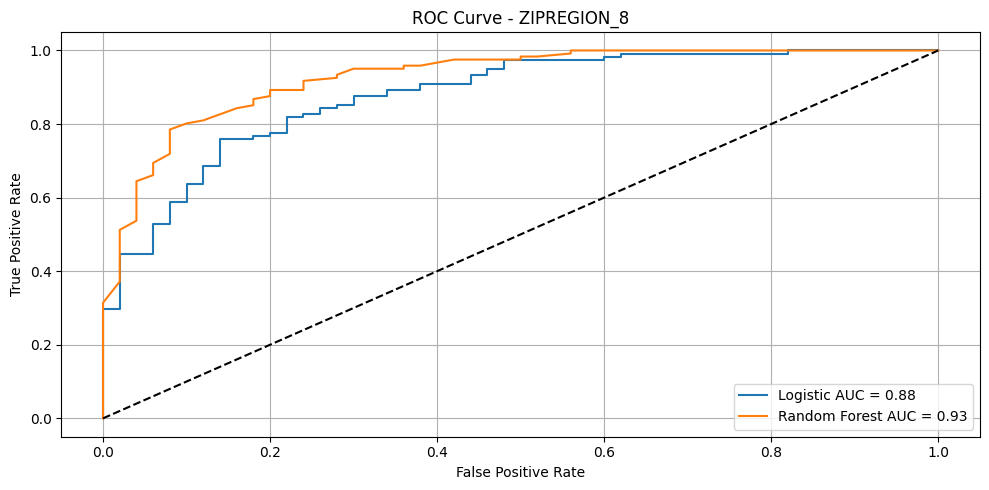

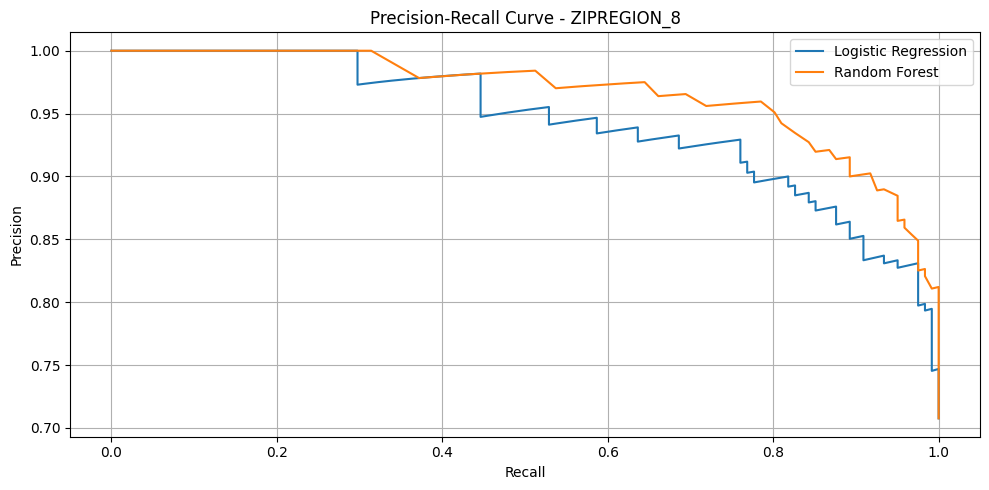



========== Analysis for ZIPREGION_9 ==========

=== Logistic Regression ===
Accuracy: 0.8715596330275229
Confusion Matrix:
 [[ 70  30]
 [ 12 215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.70      0.77       100
           1       0.88      0.95      0.91       227

    accuracy                           0.87       327
   macro avg       0.87      0.82      0.84       327
weighted avg       0.87      0.87      0.87       327


=== Decision Tree ===
Accuracy: 0.8960244648318043
Confusion Matrix:
 [[ 79  21]
 [ 13 214]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82       100
           1       0.91      0.94      0.93       227

    accuracy                           0.90       327
   macro avg       0.88      0.87      0.87       327
weighted avg       0.89      0.90      0.89       327


=== Random Forest ===
Accuracy: 0.9204892966360856
Con

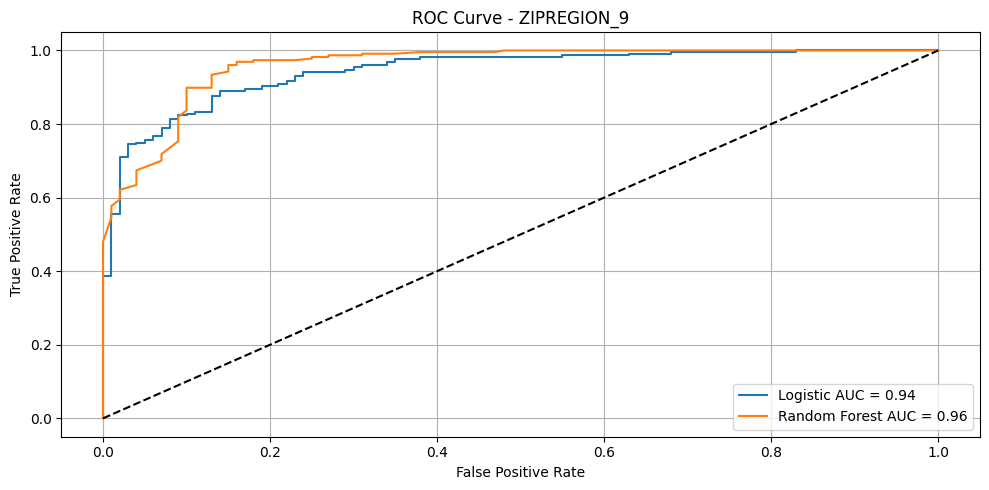

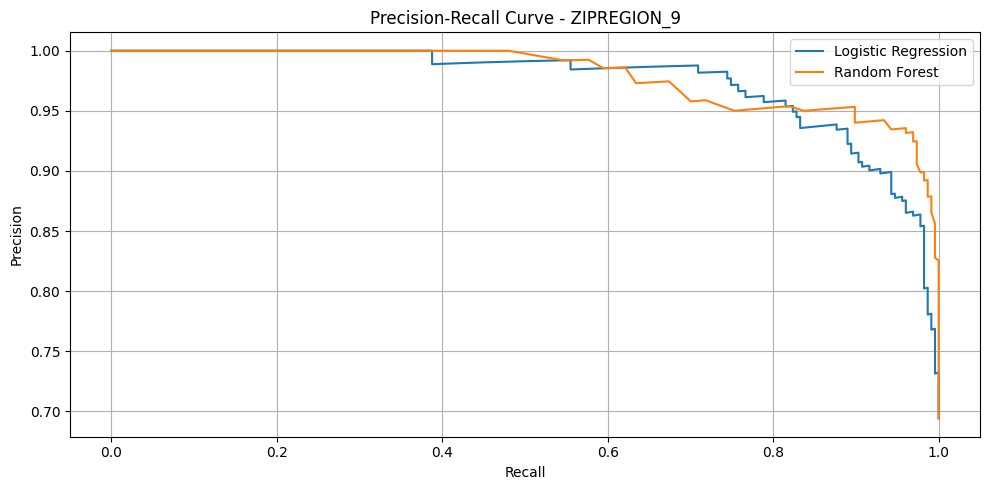


=== Skipped ZIPREGIONs Summary ===
ZIPREGION_1: Only class 1 (1854 rows)
ZIPREGION_7: Only class 1 (3116 rows)

Skipped regions exported to Skipped_Regions_Summary.csv


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt

# Load your data
df_original = pd.read_csv("FinalClean_15.csv")
zipregion_cols = [f'ZIPREGION_{i}' for i in range(1, 10)]
skipped_regions = []

for zip_col in zipregion_cols:
    print(f"\n\n========== Analysis for {zip_col} ==========\n")
    df = df_original[df_original[zip_col] == 1].copy()

    if df.shape[0] < 50:
        print(f"Skipping {zip_col} — not enough data ({df.shape[0]} rows).")
        skipped_regions.append((zip_col, "Too few rows", df.shape[0]))
        continue

    df = df[df['Year'].isin([2018, 2019])]
    threshold = df['Score_High'].median()
    df['Score_High_Binary'] = (df['Score_High'] >= threshold).astype(int)
    y = df["Score_High_Binary"]

    if y.nunique() < 2:
        dominant_class = y.unique()[0]
        print(f"Skipping {zip_col} — only one class present: {dominant_class}")
        skipped_regions.append((zip_col, f"Only class {dominant_class}", len(y)))
        continue

    s_f1 = [
        "quality_rating", "staffing_rating", "DeficiencyCount", "adj_total",
        "short_stay_poor_quality", "short_stay_good_quality",
        "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"
    ]
    X = df[s_f1]
    y = df["Score_High_Binary"]

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # === Logistic Regression ===
    log_model = LogisticRegression()
    log_model.fit(X_train_scaled, y_train)
    y_pred_log = log_model.predict(X_test_scaled)
    y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

    print("=== Logistic Regression ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_log))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
    print("Classification Report:\n", classification_report(y_test, y_pred_log))

    # === Decision Tree ===
    tree_model = DecisionTreeClassifier(random_state=42)
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    print("\n=== Decision Tree ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_tree))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
    print("Classification Report:\n", classification_report(y_test, y_pred_tree))

    # === Random Forest ===
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

    print("\n=== Random Forest ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print("Classification Report:\n", classification_report(y_test, y_pred_rf))

    # === ROC Curve ===
    fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    auc_log = auc(fpr_log, tpr_log)
    auc_rf = auc(fpr_rf, tpr_rf)

    plt.figure(figsize=(10, 5))
    plt.plot(fpr_log, tpr_log, label=f'Logistic AUC = {auc_log:.2f}')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest AUC = {auc_rf:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {zip_col}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === Precision-Recall Curve ===
    precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_log)
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)

    plt.figure(figsize=(10, 5))
    plt.plot(recall_log, precision_log, label='Logistic Regression')
    plt.plot(recall_rf, precision_rf, label='Random Forest')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {zip_col}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Summary of Skipped ZIPREGIONs ===
if skipped_regions:
    print("\n=== Skipped ZIPREGIONs Summary ===")
    for region, reason, count in skipped_regions:
        print(f"{region}: {reason} ({count} rows)")

    pd.DataFrame(skipped_regions, columns=['ZIPREGION', 'Reason', 'Row_Count']) \
      .to_csv("Skipped_Regions_Summary.csv", index=False)
    print("\nSkipped regions exported to Skipped_Regions_Summary.csv")
else:
    print("\nAll ZIPREGIONs included — no regions skipped.")




========== Analysis for ZIPREGION_1 ==========

Skipping ZIPREGION_1 — only one class present: 1


========== Analysis for ZIPREGION_2 ==========

=== Logistic Regression ===
Accuracy: 0.7965116279069767
Confusion Matrix:
 [[143  38]
 [ 32 131]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80       181
           1       0.78      0.80      0.79       163

    accuracy                           0.80       344
   macro avg       0.80      0.80      0.80       344
weighted avg       0.80      0.80      0.80       344


=== Decision Tree ===
Accuracy: 0.8372093023255814
Confusion Matrix:
 [[149  32]
 [ 24 139]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       181
           1       0.81      0.85      0.83       163

    accuracy                           0.84       344
   macro avg       0.84      0.84      0.84       344
weighted av

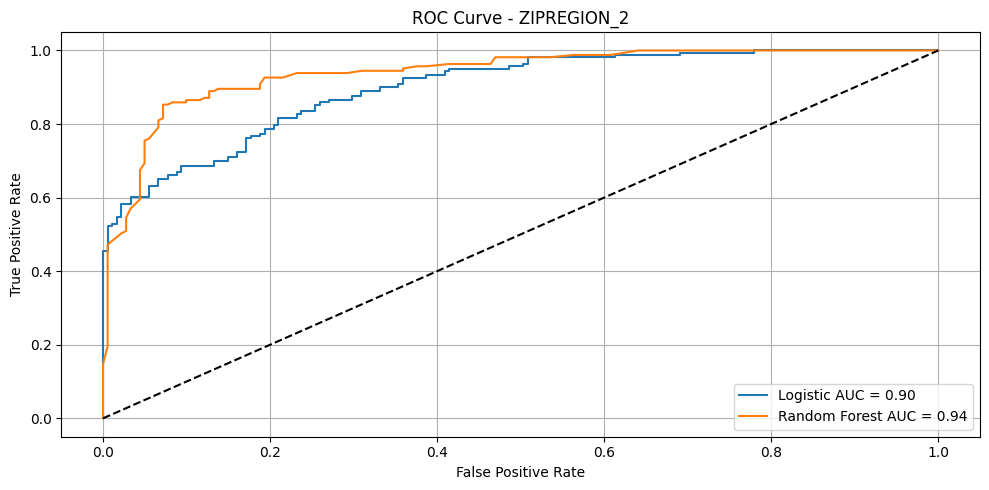

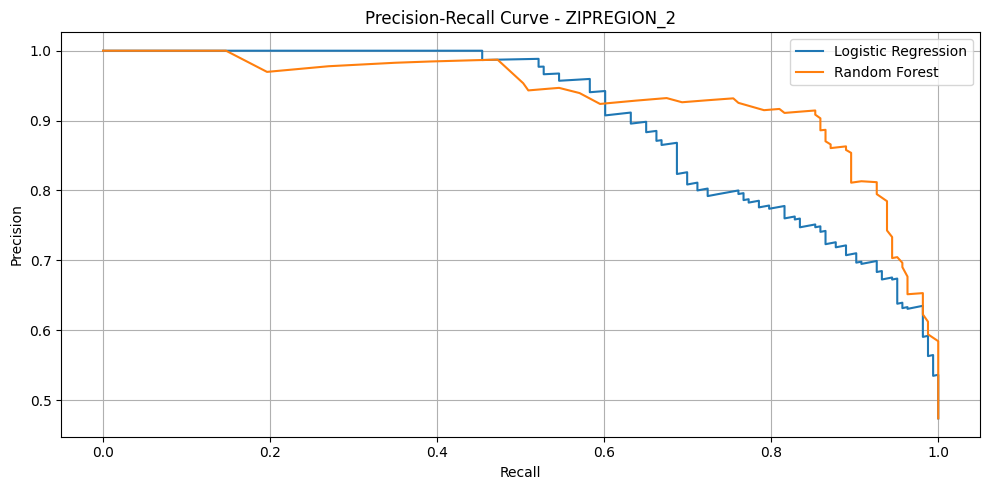



========== Analysis for ZIPREGION_3 ==========

=== Logistic Regression ===
Accuracy: 0.8091993185689949
Confusion Matrix:
 [[193  65]
 [ 47 282]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.78       258
           1       0.81      0.86      0.83       329

    accuracy                           0.81       587
   macro avg       0.81      0.80      0.80       587
weighted avg       0.81      0.81      0.81       587


=== Decision Tree ===
Accuracy: 0.8432708688245315
Confusion Matrix:
 [[212  46]
 [ 46 283]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       258
           1       0.86      0.86      0.86       329

    accuracy                           0.84       587
   macro avg       0.84      0.84      0.84       587
weighted avg       0.84      0.84      0.84       587


=== Random Forest ===
Accuracy: 0.889267461669506
Conf

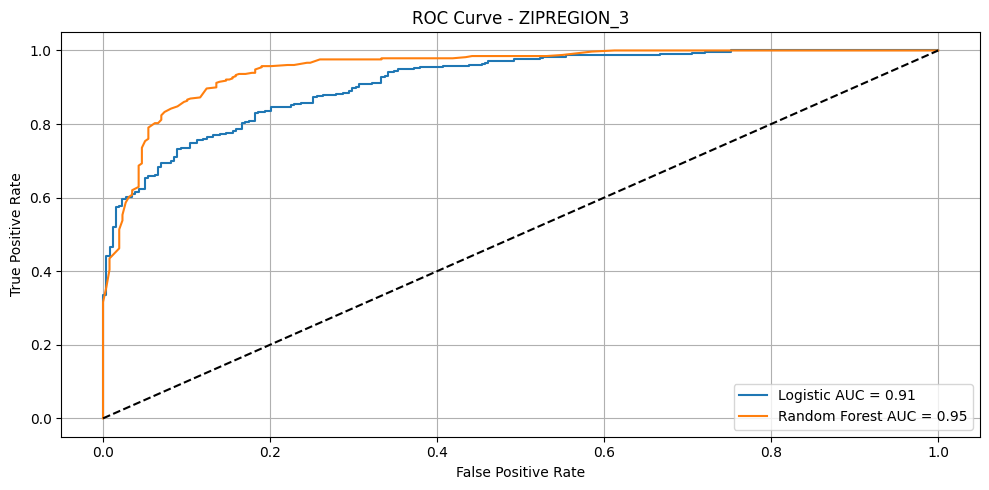

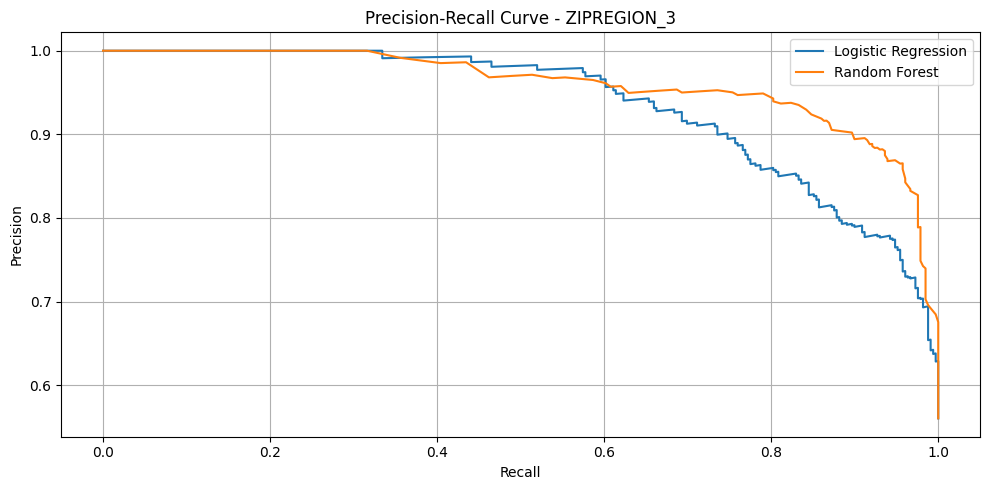



========== Analysis for ZIPREGION_4 ==========

=== Logistic Regression ===
Accuracy: 0.807936507936508
Confusion Matrix:
 [[190  59]
 [ 62 319]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.76      0.76       249
           1       0.84      0.84      0.84       381

    accuracy                           0.81       630
   macro avg       0.80      0.80      0.80       630
weighted avg       0.81      0.81      0.81       630


=== Decision Tree ===
Accuracy: 0.8920634920634921
Confusion Matrix:
 [[219  30]
 [ 38 343]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87       249
           1       0.92      0.90      0.91       381

    accuracy                           0.89       630
   macro avg       0.89      0.89      0.89       630
weighted avg       0.89      0.89      0.89       630


=== Random Forest ===
Accuracy: 0.9222222222222223
Conf

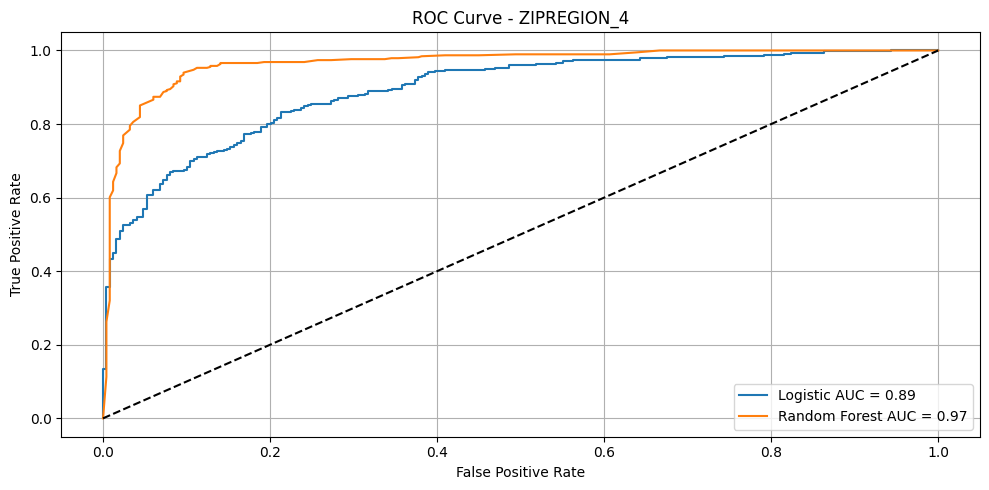

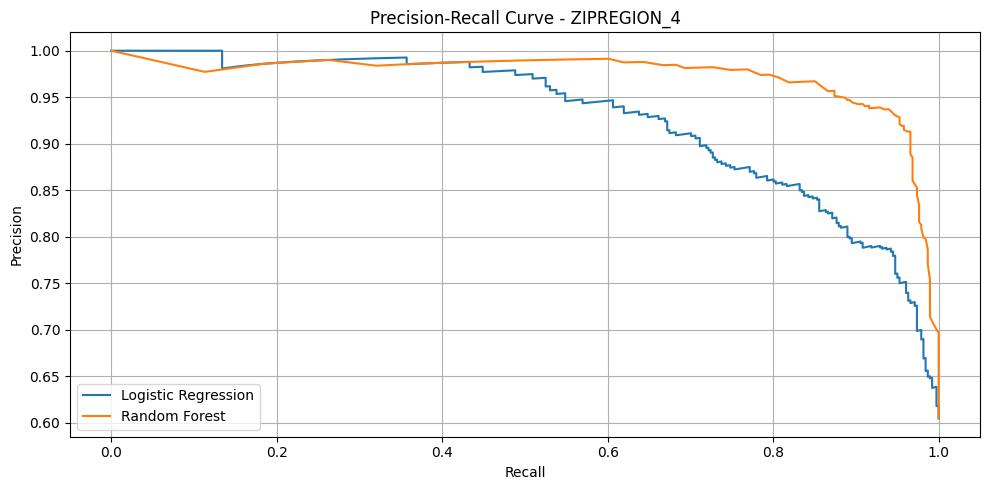



========== Analysis for ZIPREGION_5 ==========

=== Logistic Regression ===
Accuracy: 0.8650442477876106
Confusion Matrix:
 [[ 93  42]
 [ 19 298]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       135
           1       0.88      0.94      0.91       317

    accuracy                           0.87       452
   macro avg       0.85      0.81      0.83       452
weighted avg       0.86      0.87      0.86       452


=== Decision Tree ===
Accuracy: 0.9026548672566371
Confusion Matrix:
 [[111  24]
 [ 20 297]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83       135
           1       0.93      0.94      0.93       317

    accuracy                           0.90       452
   macro avg       0.89      0.88      0.88       452
weighted avg       0.90      0.90      0.90       452


=== Random Forest ===
Accuracy: 0.9247787610619469
Con

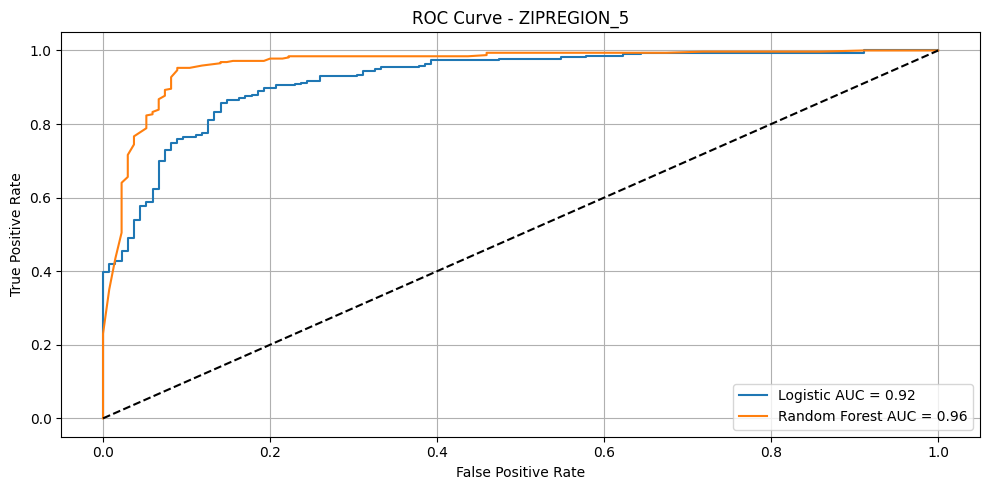

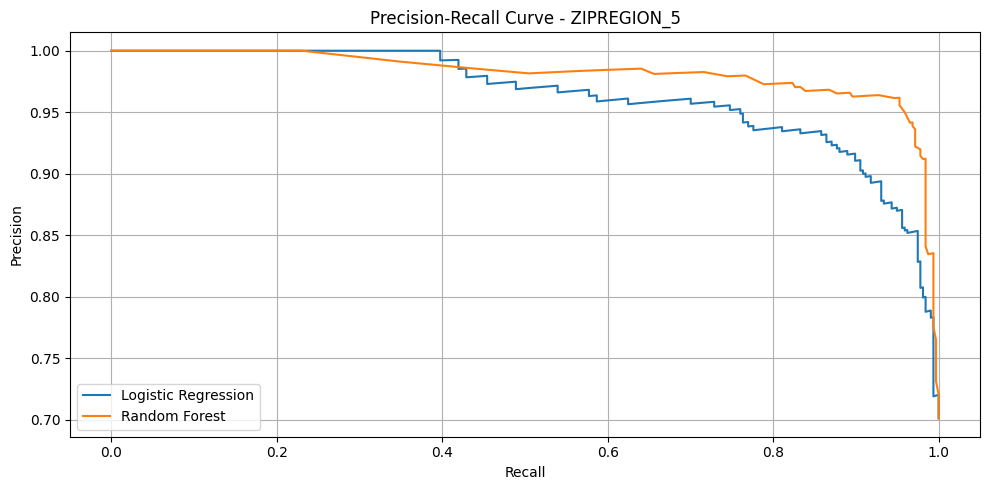



========== Analysis for ZIPREGION_6 ==========

=== Logistic Regression ===
Accuracy: 0.789010989010989
Confusion Matrix:
 [[116  55]
 [ 41 243]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.68      0.71       171
           1       0.82      0.86      0.84       284

    accuracy                           0.79       455
   macro avg       0.78      0.77      0.77       455
weighted avg       0.79      0.79      0.79       455


=== Decision Tree ===
Accuracy: 0.8725274725274725
Confusion Matrix:
 [[150  21]
 [ 37 247]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       171
           1       0.92      0.87      0.89       284

    accuracy                           0.87       455
   macro avg       0.86      0.87      0.87       455
weighted avg       0.88      0.87      0.87       455


=== Random Forest ===
Accuracy: 0.8703296703296703
Conf

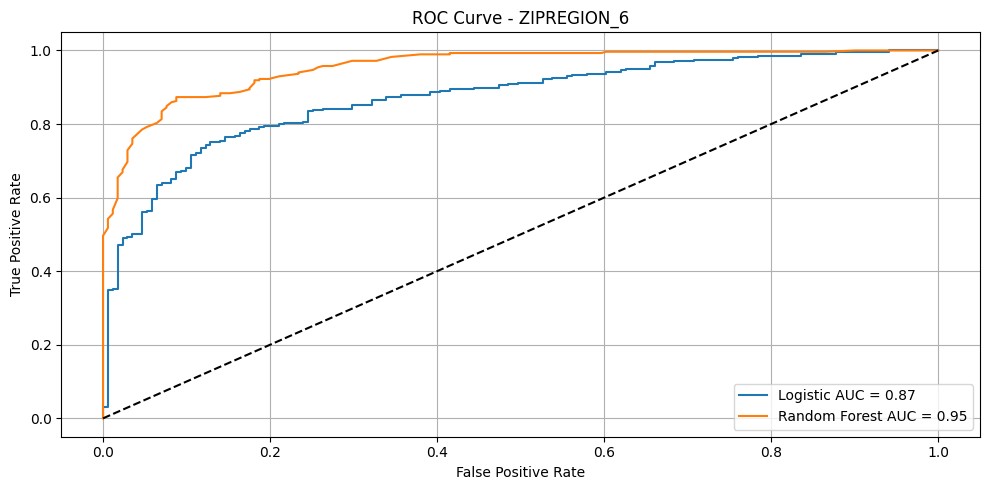

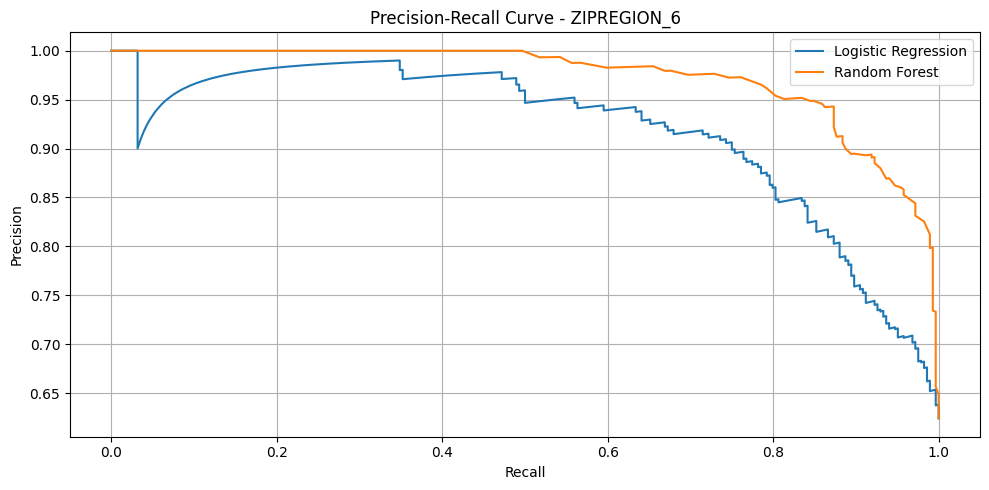



========== Analysis for ZIPREGION_7 ==========

Skipping ZIPREGION_7 — only one class present: 1


========== Analysis for ZIPREGION_8 ==========

=== Logistic Regression ===
Accuracy: 0.8245614035087719
Confusion Matrix:
 [[ 28  22]
 [  8 113]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.56      0.65        50
           1       0.84      0.93      0.88       121

    accuracy                           0.82       171
   macro avg       0.81      0.75      0.77       171
weighted avg       0.82      0.82      0.82       171


=== Decision Tree ===
Accuracy: 0.847953216374269
Confusion Matrix:
 [[ 35  15]
 [ 11 110]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.70      0.73        50
           1       0.88      0.91      0.89       121

    accuracy                           0.85       171
   macro avg       0.82      0.80      0.81       171
weighted avg

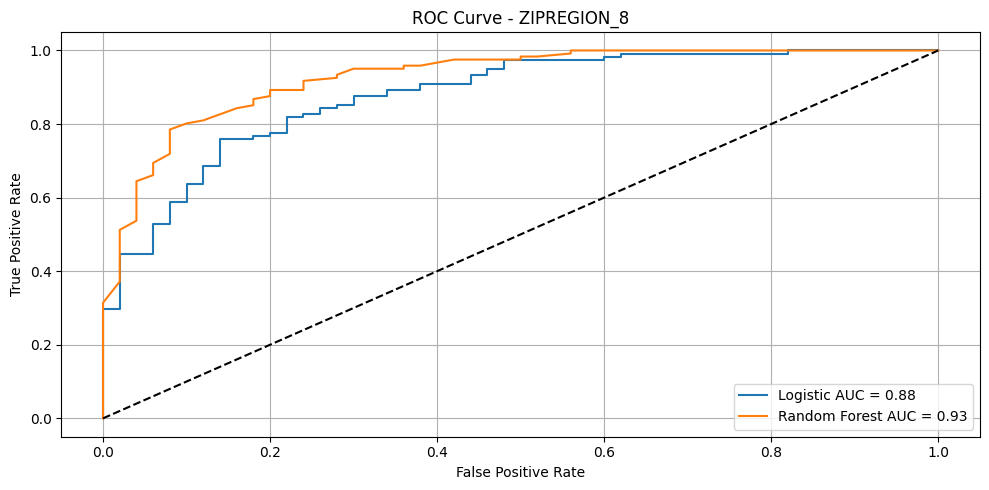

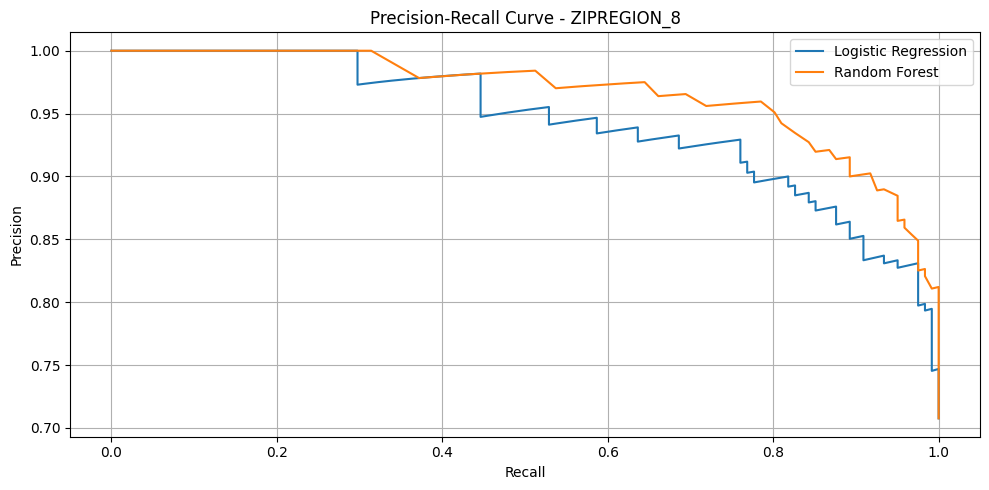



========== Analysis for ZIPREGION_9 ==========

=== Logistic Regression ===
Accuracy: 0.8715596330275229
Confusion Matrix:
 [[ 70  30]
 [ 12 215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.70      0.77       100
           1       0.88      0.95      0.91       227

    accuracy                           0.87       327
   macro avg       0.87      0.82      0.84       327
weighted avg       0.87      0.87      0.87       327


=== Decision Tree ===
Accuracy: 0.8960244648318043
Confusion Matrix:
 [[ 79  21]
 [ 13 214]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82       100
           1       0.91      0.94      0.93       227

    accuracy                           0.90       327
   macro avg       0.88      0.87      0.87       327
weighted avg       0.89      0.90      0.89       327


=== Random Forest ===
Accuracy: 0.9204892966360856
Con

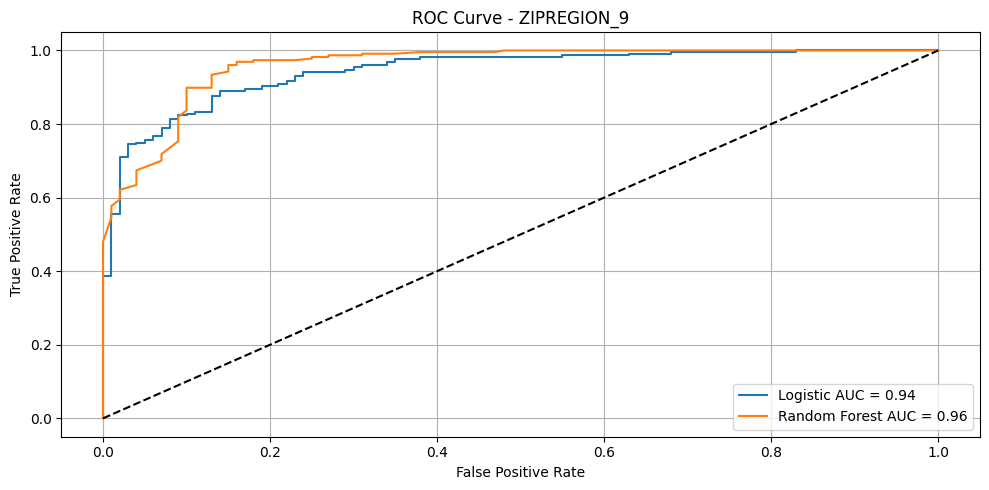

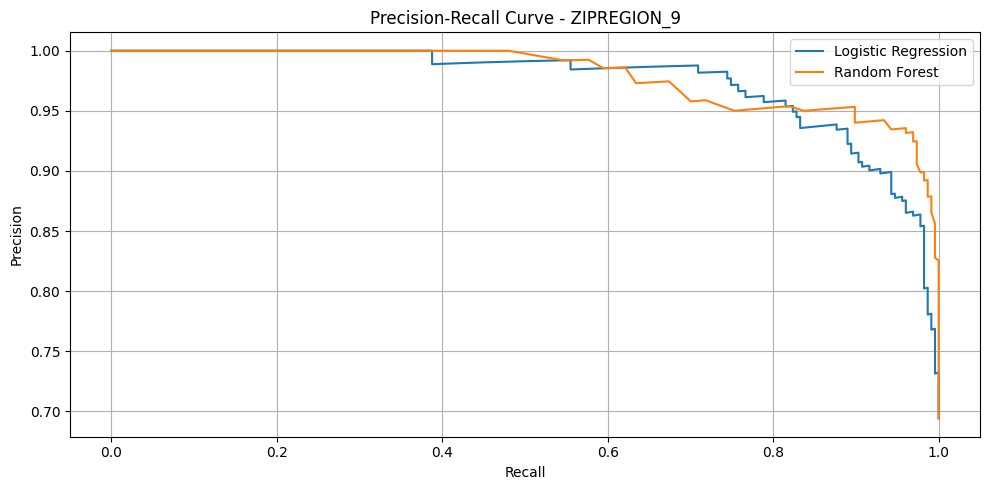


=== Skipped ZIPREGIONs Summary ===
ZIPREGION_1: Only class 1 (1854 rows)
ZIPREGION_7: Only class 1 (3116 rows)

Skipped regions exported to Skipped_Regions_Summary.csv


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt

# Load your data
df_original = pd.read_csv("FinalClean_15.csv")
zipregion_cols = [f'ZIPREGION_{i}' for i in range(1, 10)]
skipped_regions = []

for zip_col in zipregion_cols:
    print(f"\n\n========== Analysis for {zip_col} ==========\n")
    df = df_original[df_original[zip_col] == 1].copy()

    if df.shape[0] < 50:
        print(f"Skipping {zip_col} — not enough data ({df.shape[0]} rows).")
        skipped_regions.append((zip_col, "Too few rows", df.shape[0]))
        continue

    df = df[df['Year'].isin([2018, 2019])]
    threshold = df['Score_High'].median()
    df['Score_High_Binary'] = (df['Score_High'] >= threshold).astype(int)
    y = df["Score_High_Binary"]

    if y.nunique() < 2:
        dominant_class = y.unique()[0]
        print(f"Skipping {zip_col} — only one class present: {dominant_class}")
        skipped_regions.append((zip_col, f"Only class {dominant_class}", len(y)))
        continue

    s_f1 = [
        "quality_rating", "staffing_rating", "DeficiencyCount", "adj_total",
        "short_stay_poor_quality", "short_stay_good_quality",
        "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"
    ]
    X = df[s_f1]
    y = df["Score_High_Binary"]

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # === Logistic Regression ===
    log_model = LogisticRegression()
    log_model.fit(X_train_scaled, y_train)
    y_pred_log = log_model.predict(X_test_scaled)
    y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

    print("=== Logistic Regression ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_log))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
    print("Classification Report:\n", classification_report(y_test, y_pred_log))

    # === Decision Tree ===
    tree_model = DecisionTreeClassifier(random_state=42)
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    print("\n=== Decision Tree ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_tree))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
    print("Classification Report:\n", classification_report(y_test, y_pred_tree))

    # === Random Forest ===
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

    print("\n=== Random Forest ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print("Classification Report:\n", classification_report(y_test, y_pred_rf))

    # === ROC Curve ===
    fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    auc_log = auc(fpr_log, tpr_log)
    auc_rf = auc(fpr_rf, tpr_rf)

    plt.figure(figsize=(10, 5))
    plt.plot(fpr_log, tpr_log, label=f'Logistic AUC = {auc_log:.2f}')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest AUC = {auc_rf:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {zip_col}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # === Precision-Recall Curve ===
    precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_log)
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)

    plt.figure(figsize=(10, 5))
    plt.plot(recall_log, precision_log, label='Logistic Regression')
    plt.plot(recall_rf, precision_rf, label='Random Forest')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {zip_col}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Summary of Skipped ZIPREGIONs ===
if skipped_regions:
    print("\n=== Skipped ZIPREGIONs Summary ===")
    for region, reason, count in skipped_regions:
        print(f"{region}: {reason} ({count} rows)")

    pd.DataFrame(skipped_regions, columns=['ZIPREGION', 'Reason', 'Row_Count']) \
      .to_csv("Skipped_Regions_Summary.csv", index=False)
    print("\nSkipped regions exported to Skipped_Regions_Summary.csv")
else:
    print("\nAll ZIPREGIONs included — no regions skipped.")




========== Analysis for ZIPREGION_1 ==========

=== Logistic Regression ===
Accuracy: 0.8992443324937027
Confusion Matrix:
 [[465  62]
 [ 58 606]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89       527
           1       0.91      0.91      0.91       664

    accuracy                           0.90      1191
   macro avg       0.90      0.90      0.90      1191
weighted avg       0.90      0.90      0.90      1191


=== Decision Tree ===
Accuracy: 0.9252728799328296
Confusion Matrix:
 [[486  41]
 [ 48 616]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       527
           1       0.94      0.93      0.93       664

    accuracy                           0.93      1191
   macro avg       0.92      0.92      0.92      1191
weighted avg       0.93      0.93      0.93      1191


=== Random Forest ===
Accuracy: 0.9571788413098237
Con

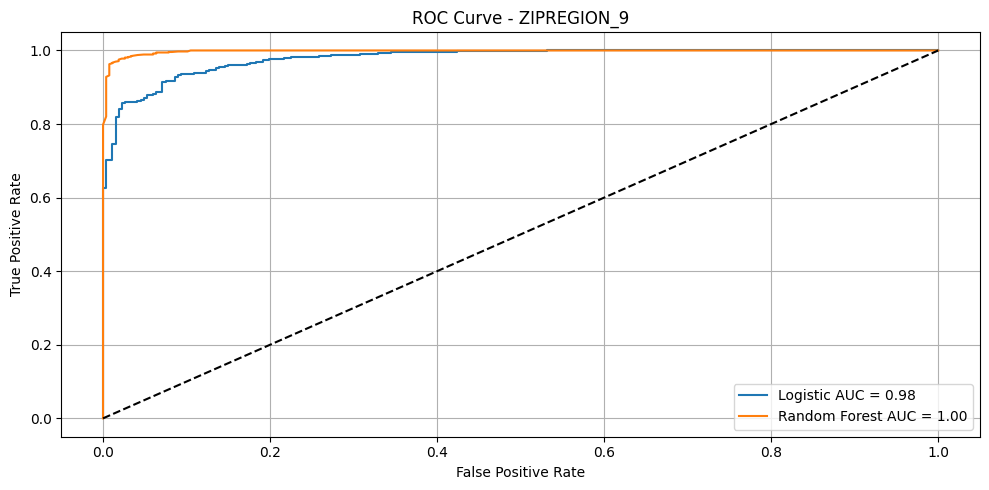

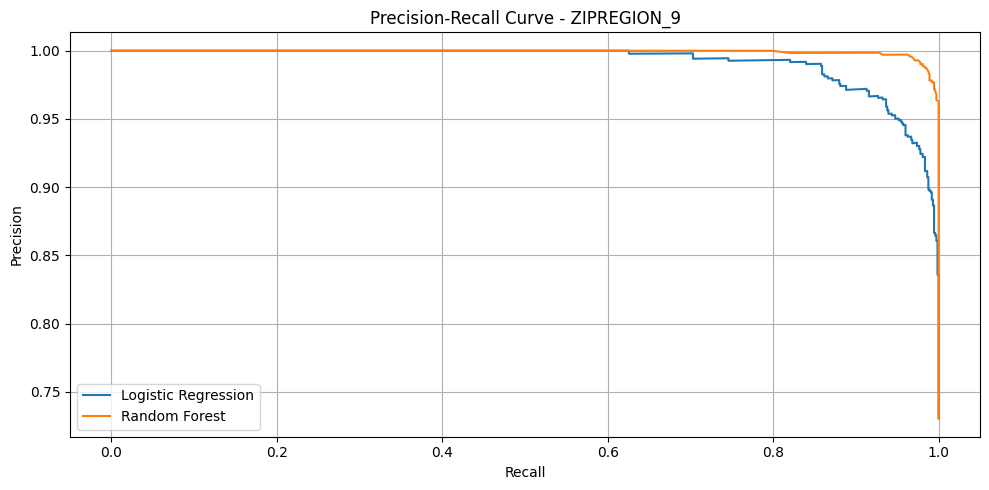


All ZIPREGIONs included — no regions skipped.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt

# Load your data
df_original = pd.read_csv("FinalCategorizationProvider_Data.csv")
zipregion_cols = [f'ZIPREGION_{i}' for i in range(1, 10)]
skipped_regions = []

# Filter full dataset to 2020 and 2021 first
df_filtered = df_original[df_original['Year'].isin([2015, 2016, 2017, 2018, 2019, 2020, 2021])].copy()

# Compute a global median from this filtered dataset
global_threshold = df_filtered['Score_High'].median()


for zip_col in zipregion_cols:
    print(f"\n\n========== Analysis for {zip_col} ==========\n")

    df = df_filtered[df_filtered[zip_col] == 1].copy()

    if df.shape[0] < 50:
        print(f"Skipping {zip_col} — not enough data ({df.shape[0]} rows).")
        skipped_regions.append((zip_col, "Too few rows", df.shape[0]))
        continue

    # Use global threshold
    df['Score_High_Binary'] = (df['Score_High'] >= global_threshold).astype(int)
    y = df["Score_High_Binary"]

    if y.nunique() < 2:
        dominant_class = y.unique()[0]
        print(f"⚠️ Warning: Only class {dominant_class} present in {zip_col}. Proceeding, but some metrics may fail.")

    s_f1 = ["quality_rating", "staffing_rating", "DeficiencyCount", "adj_total","WEIGHTED_ALL_CYCLES_SCORE", 
        "cmplnt_cnt", "BEDCERT", "RESTOT", "short_stay_poor_quality", "short_stay_good_quality", "long_stay_poor_quality",
        "long_stay_good_quality", "measure_score_qtravg", "OWNERSHIP_For profit", "OWNERSHIP_Government", "OWNERSHIP_Non profit",
        "CERTIFICATION_Medicaid", "CERTIFICATION_Medicare", "CERTIFICATION_Medicare and Medicaid"
        ]
    X = df[s_f1]
    y = df["Score_High_Binary"]

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # === Logistic Regression ===
    log_model = LogisticRegression()
    log_model.fit(X_train_scaled, y_train)
    y_pred_log = log_model.predict(X_test_scaled)
    y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

    print("=== Logistic Regression ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_log))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
    print("Classification Report:\n", classification_report(y_test, y_pred_log))

    # === Decision Tree ===
    tree_model = DecisionTreeClassifier(random_state=42)
    tree_model.fit(X_train, y_train)
    y_pred_tree = tree_model.predict(X_test)

    print("\n=== Decision Tree ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_tree))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
    print("Classification Report:\n", classification_report(y_test, y_pred_tree))

    # === Random Forest ===
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

    print("\n=== Random Forest ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print("Classification Report:\n", classification_report(y_test, y_pred_rf))

    # === ROC Curve ===
try:
    fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    auc_log = auc(fpr_log, tpr_log)
    auc_rf = auc(fpr_rf, tpr_rf)

    plt.figure(figsize=(10, 5))
    plt.plot(fpr_log, tpr_log, label=f'Logistic AUC = {auc_log:.2f}')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest AUC = {auc_rf:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {zip_col}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_log)
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)

    plt.figure(figsize=(10, 5))
    plt.plot(recall_log, precision_log, label='Logistic Regression')
    plt.plot(recall_rf, precision_rf, label='Random Forest')
    plt.title(f'Precision-Recall Curve - {zip_col}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"⚠️ Could not compute ROC/PR for {zip_col}: {e}")


# === Summary of Skipped ZIPREGIONs ===
if skipped_regions:
    print("\n=== Skipped ZIPREGIONs Summary ===")
    for region, reason, count in skipped_regions:
        print(f"{region}: {reason} ({count} rows)")

    pd.DataFrame(skipped_regions, columns=['ZIPREGION', 'Reason', 'Row_Count']) \
      .to_csv("Skipped_Regions_Summary.csv", index=False)
    print("\nSkipped regions exported to Skipped_Regions_Summary.csv")
else:
    print("\nAll ZIPREGIONs included — no regions skipped.")


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# Load your dataset
df = pd.read_csv("RetirementCareData.csv")  # Replace with your file

# Define features and target
features = [
    "Score_High","quality_rating", "staffing_rating", "DeficiencyCount", "adj_total",
    "short_stay_poor_quality", "short_stay_good_quality",
    "long_stay_poor_quality", "long_stay_good_quality", "measure_score_qtravg"
]
target = "Net_income_per_discharge"

X = df[features].copy()
y = df[target].copy()

# Handle categorical variables if any (e.g., ZIPREGION)
X = pd.get_dummies(X, drop_first=True)

# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features for Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Lasso Regression ===
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_train_scaled, y_train)
best_alpha = lasso_cv.alpha_
print(f"Best alpha from cross-validation: {best_alpha:.4f}")

lasso = Lasso(alpha=best_alpha)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("\n=== Lasso Regression ===")
print("R^2 Score:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Coefficients:")
for name, coef in zip(X.columns, lasso.coef_):
    print(f"{name}: {coef:.4f}")

# === OLS Regression ===
X_train_ols = sm.add_constant(X_train)  # Add intercept term
ols_model = sm.OLS(y_train, X_train_ols).fit()
print("\n=== OLS Regression Summary ===")
print(ols_model.summary())


ModuleNotFoundError: No module named 'statsmodels'